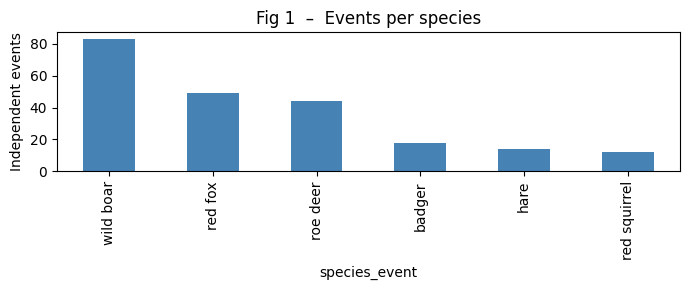

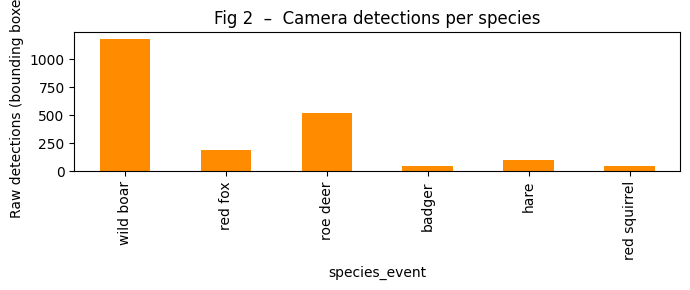

/tmp/ipykernel_2952158/79991515.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=species_order, vert=False,


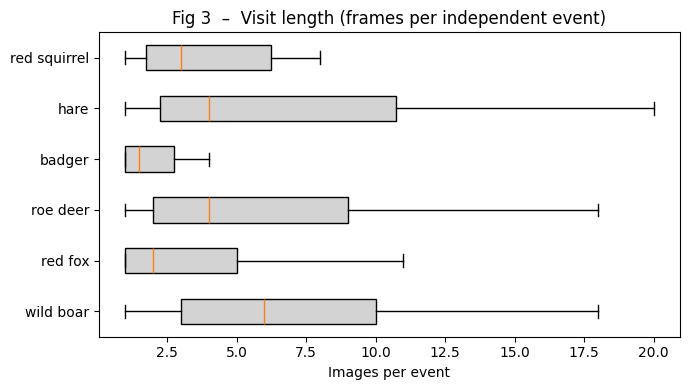

In [1]:
# ===============================================================
#  Camera-trap seminar  ·  STEP 1 — occurrence & detection pressure
#    • Fig 1  = independent events per species
#    • Fig 2  = raw detections (bounding-boxes) per species
#    • Fig 3  = images-per-event distribution (how long each visit lasts)
# ---------------------------------------------------------------
#  Requires:  event_summary.json
#             speciesnet_with_moonphase.json          (raw detections)
# ===============================================================

import json, itertools
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 0.  file locations – edit if your paths are different
# -----------------------------------------------------------------
DATA_DIR         = Path('../data/camera_trap_dataset_filtered')                 # folder that holds the JSON files
EVENT_FILE       = DATA_DIR/'event_summary.json'
DETECTIONS_FILE  = DATA_DIR/'speciesnet_with_moonphase.json'

# -----------------------------------------------------------------
# 1.  load event summary  →  events_df
# -----------------------------------------------------------------
events_raw = json.loads(EVENT_FILE.read_text())
events_df  = (pd.json_normalize(events_raw)
                .explode('species', ignore_index=True)    # one row per event-species combo
                .rename(columns={'species':'species_event'}))

# images per event (needed later)
events_df['img_cnt'] = events_df['images'].apply(len)

# -----------------------------------------------------------------
# 2.  load *raw* detections  →  dets_df
# -----------------------------------------------------------------
dets_raw = json.loads(DETECTIONS_FILE.read_text())['predictions']

records = []
for rec in dets_raw:
    tstamp   = pd.to_datetime(rec['timestamp'])
    for det in rec['detections']:
        # take the first class label (there is always exactly one in your file)
        sp = det['classifications']['classes'][0]
        records.append({'timestamp': tstamp, 'species_det': sp})

dets_df = pd.DataFrame.from_records(records)

# -----------------------------------------------------------------
# 3.  Figure 1 – independent events per species
# -----------------------------------------------------------------
fig1_counts = (events_df['species_event']
               .value_counts()
               .sort_values(ascending=False))

plt.figure(figsize=(7,3))
fig1_counts.plot(kind='bar', color='steelblue')
plt.ylabel('Independent events')
plt.title('Fig 1  –  Events per species')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 4.  Figure 2 – raw detections per species
# -----------------------------------------------------------------
fig2_counts = (dets_df['species_det']
               .value_counts()
               .reindex(fig1_counts.index, fill_value=0))

plt.figure(figsize=(7,3))
fig2_counts.plot(kind='bar', color='darkorange')
plt.ylabel('Raw detections (bounding boxes)')
plt.title('Fig 2  –  Camera detections per species')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 5.  Figure 3 – images per event (how long a visit lasts)
# -----------------------------------------------------------------
# use same species order as Fig 1 for consistency
species_order = fig1_counts.index.tolist()
box_data = [events_df
            .loc[events_df['species_event']==sp, 'img_cnt']
            .values
            for sp in species_order]

plt.figure(figsize=(7,4))
plt.boxplot(box_data, labels=species_order, vert=False,
            showfliers=False, patch_artist=True,
            boxprops={'facecolor':'lightgrey'})
plt.xlabel('Images per event')
plt.title('Fig 3  –  Visit length (frames per independent event)')
plt.tight_layout()
plt.show()


In [2]:
dets_df

,timestamp,species_det
0,2025-02-02 00:12:04,wild boar
1,2025-02-02 00:12:04,wild boar
2,2025-02-02 00:12:05,wild boar
3,2025-02-02 00:12:06,wild boar
4,2025-02-02 00:12:07,wild boar
...,...,...
2072,2025-05-10 01:31:40,hare
2073,2025-05-10 04:42:34,wild boar
2074,2025-05-10 05:29:04,wild boar
2075,2025-05-11 07:11:09,roe deer


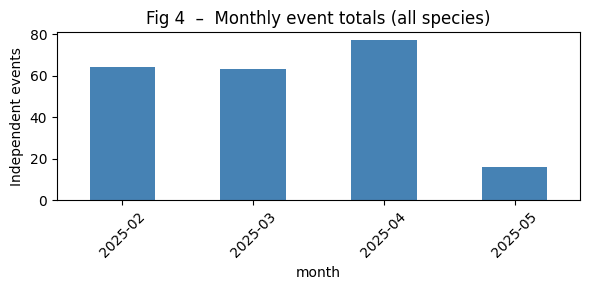

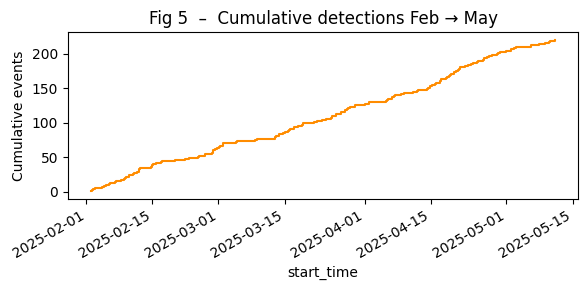

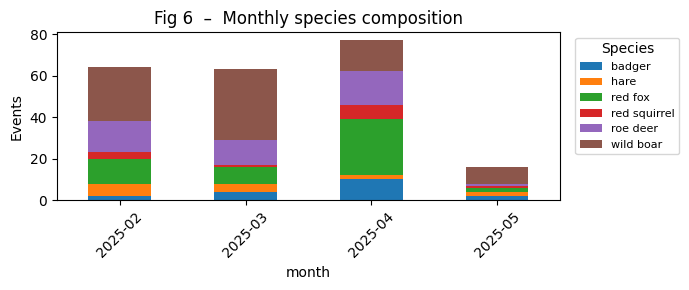

In [3]:
# ===============================================================
#  STEP 3 – TEMPORAL TRENDS
#    • Fig 4  = monthly event counts
#    • Fig 5  = cumulative events curve
#    • Fig 6  = stacked monthly counts by species
# ---------------------------------------------------------------
#  Requires:  event_summary.json   (same file you uploaded)
# ===============================================================

import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 0.  load events
# ---------------------------------------------------------------
EVENT_FILE = DATA_DIR/Path("event_summary.json")      # adjust if in sub-folder

events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species":"species_event"}))

events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["month"]      = events_df["start_time"].dt.to_period("M")

# ---------------------------------------------------------------
# 1.  Fig 4 – monthly total event counts (all species)
# ---------------------------------------------------------------
fig4_counts = (events_df.groupby("month")
                         .size()
                         .sort_index())

plt.figure(figsize=(6,3))
fig4_counts.plot(kind="bar", color="steelblue")
plt.ylabel("Independent events")
plt.title("Fig 4  –  Monthly event totals (all species)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 2.  Fig 5 – cumulative events over time
# ---------------------------------------------------------------
events_sorted = events_df.sort_values("start_time")
cum = pd.Series(range(1, len(events_sorted)+1),
                index=events_sorted["start_time"])

plt.figure(figsize=(6,3))
cum.plot(drawstyle="steps-post", color="darkorange")
plt.ylabel("Cumulative events")
plt.title("Fig 5  –  Cumulative detections Feb → May")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 3.  Fig 6 – stacked monthly counts by species
# ---------------------------------------------------------------
stack = (events_df.groupby(["month", "species_event"])
                   .size()
                   .unstack(fill_value=0)
                   .sort_index())

stack.plot(kind="bar", stacked=True, figsize=(7,3))
plt.ylabel("Events")
plt.title("Fig 6  –  Monthly species composition")
plt.xticks(rotation=45)
plt.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left",
           fontsize=8)
plt.tight_layout()
plt.show()


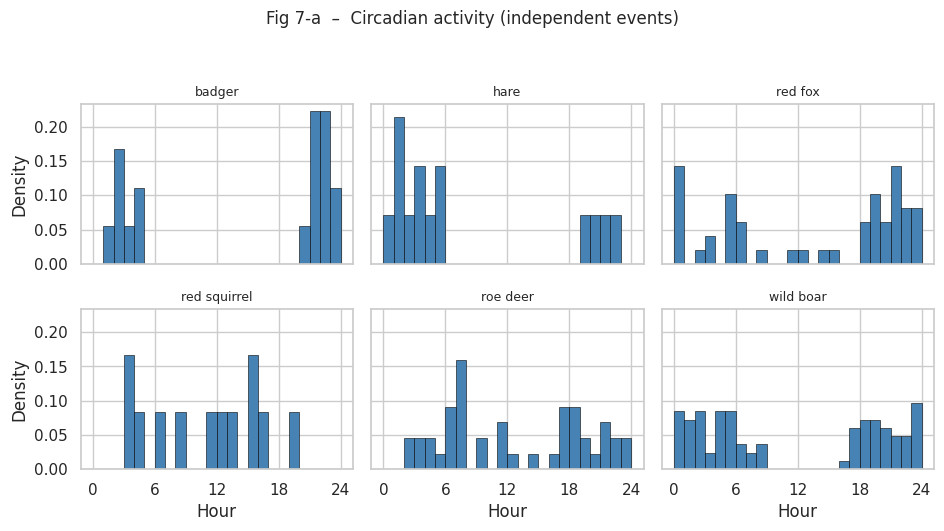

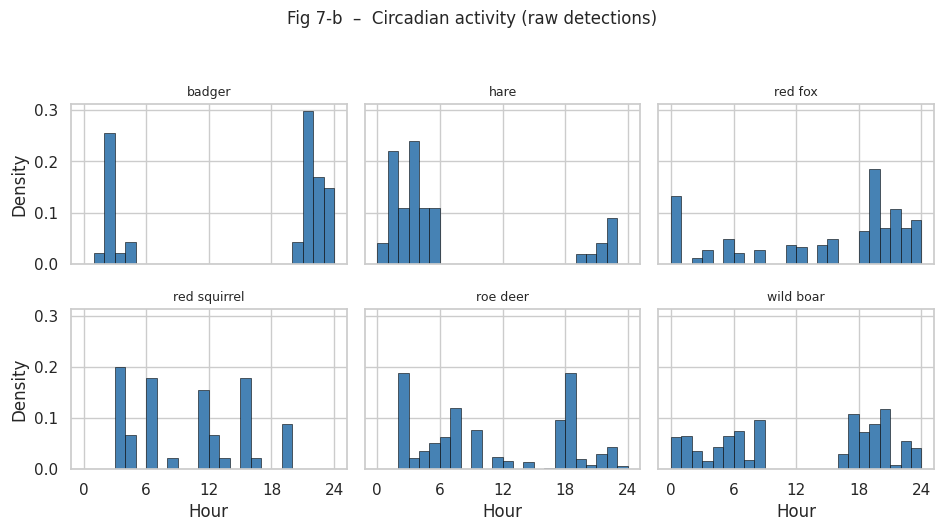

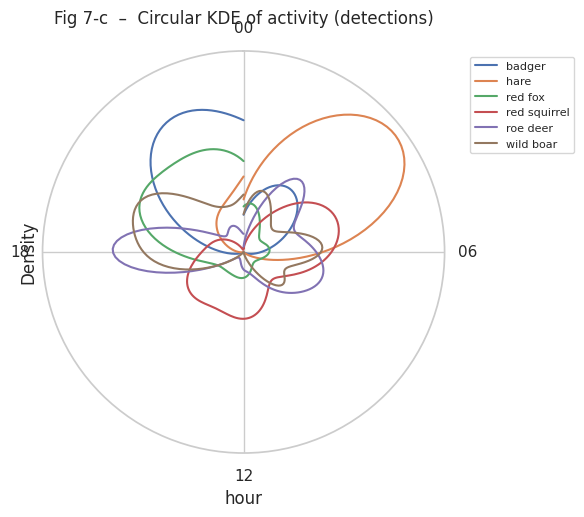

In [4]:
# ===============================================================
#  STEP 4 – Circadian activity patterns
#    • Fig 7-a  = per-species event histograms
#    • Fig 7-b  = per-species detection histograms
#    • Fig 7-c  = circular KDE curves (optional upgrade)
# ---------------------------------------------------------------
#  Requires:  event_summary.json
#             speciesnet_with_moonphase.json
# ===============================================================

import json, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

EVENT_FILE      = DATA_DIR/Path("event_summary.json")
DETECTIONS_FILE = DATA_DIR/Path("speciesnet_with_moonphase.json")

# -----------------------------------------------------------------
# 1.  Load events  → events_df with hour column
# -----------------------------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species":"species_event"}))

events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["hour"] = (events_df["start_time"].dt.hour +
                     events_df["start_time"].dt.minute/60)

# -----------------------------------------------------------------
# 2.  Load raw detections  → dets_df with hour column
# -----------------------------------------------------------------
dets_raw = json.loads(DETECTIONS_FILE.read_text())["predictions"]

rows = []
for rec in dets_raw:
    ts = pd.to_datetime(rec["timestamp"])
    for det in rec["detections"]:
        sp = det["classifications"]["classes"][0]
        rows.append({"timestamp": ts, "species_det": sp})
dets_df = pd.DataFrame(rows)
dets_df["hour"] = (dets_df["timestamp"].dt.hour +
                   dets_df["timestamp"].dt.minute/60)

# -----------------------------------------------------------------
# Helper to plot small-multiple histograms
# -----------------------------------------------------------------
def activity_hist(df, species_col, label, n_bins=24, fig_title=""):
    species = sorted(df[species_col].unique())
    n       = len(species)
    ncols   = 3
    nrows   = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols*3.2, nrows*2.7),
                             sharex=True, sharey=True)
    axes = axes.ravel()
    bins = np.linspace(0, 24, n_bins+1)

    for i, sp in enumerate(species):
        g = df.loc[df[species_col]==sp, "hour"]
        axes[i].hist(g, bins=bins, density=True,
                     color="steelblue", edgecolor="black", linewidth=0.4)
        axes[i].set_title(sp, fontsize=9)
        axes[i].set_xticks([0,6,12,18,24])
        if i // ncols == nrows-1:
            axes[i].set_xlabel("Hour")
        if i % ncols == 0:
            axes[i].set_ylabel("Density")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(fig_title, fontsize=12)
    fig.tight_layout(rect=[0,0,1,0.94])
    plt.show()

# -----------------------------------------------------------------
# 3-a.  Events histogram  (Fig 7-a)
# -----------------------------------------------------------------
activity_hist(events_df, "species_event",
              label="Events",
              fig_title="Fig 7-a  –  Circadian activity (independent events)")

# -----------------------------------------------------------------
# 3-b.  Raw detections histogram  (Fig 7-b)
# -----------------------------------------------------------------
activity_hist(dets_df, "species_det",
              label="Detections",
              fig_title="Fig 7-b  –  Circadian activity (raw detections)")

# -----------------------------------------------------------------
# 4.  OPTIONAL UPGRADE – circular kernel-density plot (Fig 7-c)
#     One polar axis with a smoothed density curve per species.
# -----------------------------------------------------------------
# Build a long frame of hours duplicated ±24 h so KDE wraps nicely
kde_rows = []
for sp, g in dets_df.groupby("species_det"):
    h = g["hour"].values
    h_wrapped = np.concatenate([h, h+24])     # wrap for circular continuity
    kde_rows.append(pd.DataFrame({"hour": h_wrapped, "species": sp}))
kde_long = pd.concat(kde_rows, ignore_index=True)

plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection="polar")

for sp in sorted(kde_long["species"].unique()):
    h = kde_long.loc[kde_long["species"]==sp, "hour"]
    theta = np.deg2rad(h / 24 * 360)          # convert to radians
    sns.kdeplot(theta, bw_adjust=0.3, ax=ax, label=sp, clip=(0, 2*np.pi), fill=False)

ax.set_theta_zero_location("N")               # 0 h = top
ax.set_theta_direction(-1)                    # clockwise
ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
ax.set_xticklabels(["00", "06", "12", "18"])
ax.set_title("Fig 7-c  –  Circular KDE of activity (detections)", pad=20)
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()




In [5]:
from astropy.coordinates import get_sun, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

# Camera location (Medvednica)
LAT, LON = 45.862184, 15.945961


# Define your camera trap location
location = EarthLocation(lat=LAT*u.deg, lon=LON*u.deg)

# Function to determine if a timestamp is during night
def is_night(timestamp):
    time = Time(timestamp)
    sun_altaz = get_sun(time).transform_to(AltAz(obstime=time, location=location))
    return sun_altaz.alt < 0*u.deg  # Sun below horizon



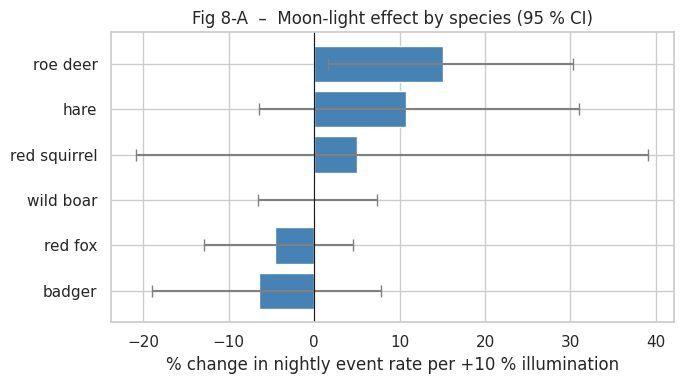

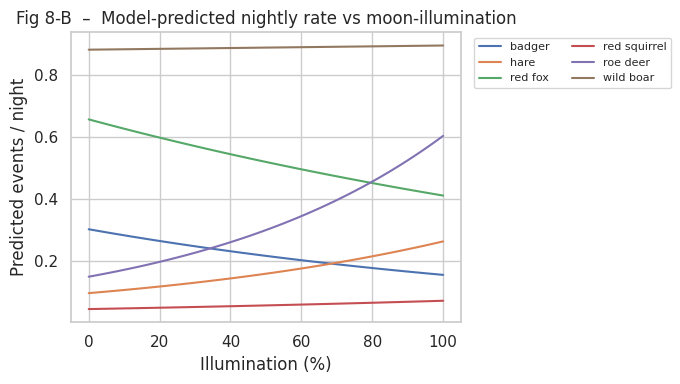


Per-species effect (% change per +10 % illumination):
(Analysis restricted to nighttime events only)


/tmp/ipykernel_2952158/852111582.py:127: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = (phase_df.pivot_table(index="moon_phase_name",


,species,pct,lo,hi,sig
0,badger,-6.5,-18.9,7.8,False
1,red fox,-4.6,-12.9,4.5,False
2,wild boar,0.2,-6.6,7.4,False
3,red squirrel,5.0,-20.8,39.1,False
4,hare,10.7,-6.5,31.0,False
5,roe deer,15.1,1.7,30.3,True



Filtering summary:
Total events: 220
Nighttime events: 158 (71.8%)


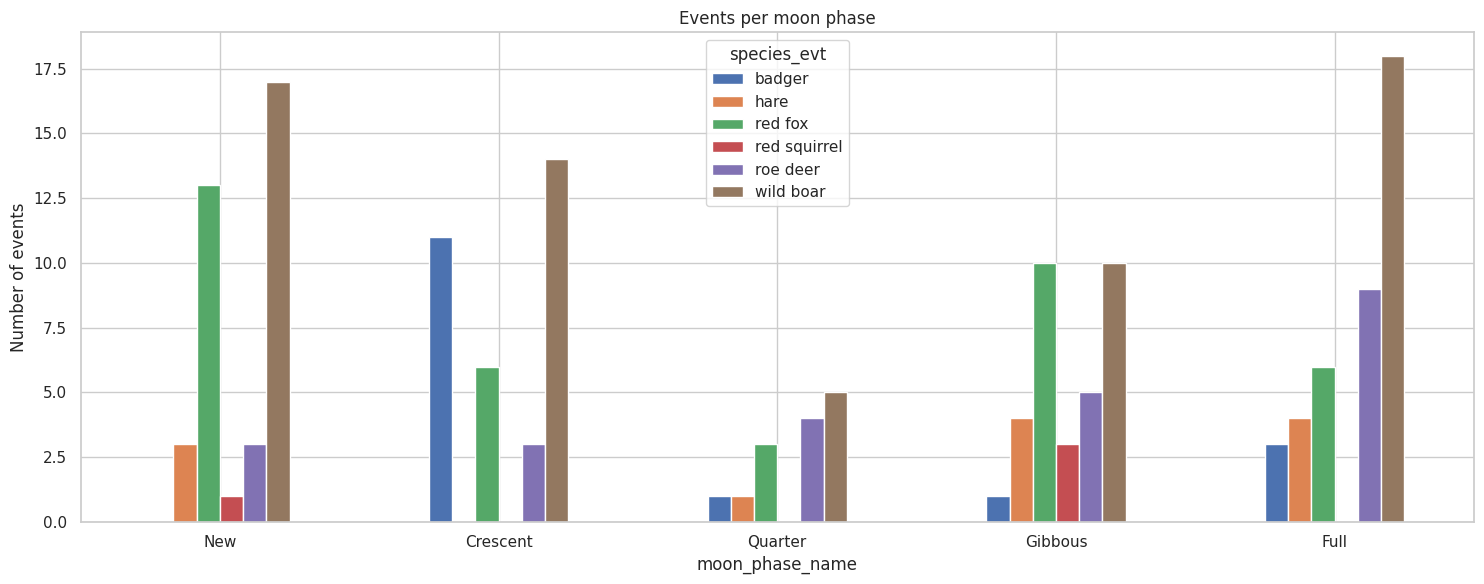

In [6]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from astropy.coordinates import get_sun, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

sns.set(style="whitegrid")

EVENT_FILE = DATA_DIR/Path("event_summary.json")       # edit if needed

CAMERA_LAT = 45.862184
CAMERA_LON = 15.945961
location = EarthLocation(lat=CAMERA_LAT*u.deg, lon=CAMERA_LON*u.deg)

# Function to determine if a timestamp is during night (sun below horizon)
def is_night(timestamp):
    time = Time(timestamp)
    sun_altaz = get_sun(time).transform_to(AltAz(obstime=time, location=location))
    return sun_altaz.alt < 0*u.deg

# ---------------------------------------------------------------
# 1.  load events  → events_df (one row / event-species)
# ---------------------------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species": "species_evt"}))

events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["night"] = events_df["start_time"].dt.floor("D")
events_df["illum_norm"] = events_df["moon_phase"] / 100       # 0-1 scale

# Apply night filtering using Astropy
# Note: This can be slow for large datasets, consider vectorizing or batch processing
events_df["is_night"] = events_df["start_time"].apply(is_night)

# Filter to include only nighttime events
night_events_df = events_df[events_df["is_night"]]

# ---------------------------------------------------------------
# 2.  nightly illumination map (global)
# ---------------------------------------------------------------
# Use the first illumination value for each night
illum_map = (night_events_df.groupby("night")["illum_norm"]
                           .first())  # nearly constant within a night

# full monitoring date index
night_idx = pd.date_range(illum_map.index.min(),
                          illum_map.index.max(),
                          freq="D")
illum_map = illum_map.reindex(night_idx)

# ---------------------------------------------------------------
# 3.  per-species nightly event counts  →  GLM fits
# ---------------------------------------------------------------
results = {}
for sp, grp in night_events_df.groupby("species_evt"):
    # count events per night, fill zeros
    cnt = (grp.groupby("night").size()
              .reindex(night_idx, fill_value=0)
              .rename("event_cnt"))

    df = pd.DataFrame({"event_cnt": cnt,
                       "illum_norm": illum_map})\
            .dropna()  # remove nights with missing illumination data

    X = sm.add_constant(df["illum_norm"])
    y = df["event_cnt"]

    mod = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    results[sp] = mod

# ---------------------------------------------------------------
# 4.  summary table (% change per +10 % illum)
# ---------------------------------------------------------------
rows = []
for sp, mod in results.items():
    beta = mod.params["illum_norm"]
    lo, hi = mod.conf_int().loc["illum_norm"]
    pct   = (np.exp(beta*0.10) - 1) * 100
    pct_lo = (np.exp(lo*0.10) - 1) * 100
    pct_hi = (np.exp(hi*0.10) - 1) * 100
    rows.append({"species": sp, "pct": pct, "lo": pct_lo, "hi": pct_hi,
                 "sig": lo*hi > 0})
df_sum = pd.DataFrame(rows).sort_values("pct").reset_index(drop=True)

# ---------------------------------------------------------------
# 5-A.  Fig 8-A – bar-chart with 95 % CIs
# ---------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.barh(df_sum["species"], df_sum["pct"],
         xerr=[df_sum["pct"]-df_sum["lo"], df_sum["hi"]-df_sum["pct"]],
         color="steelblue", capsize=4, ecolor="gray")
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("% change in nightly event rate per +10 % illumination")
plt.title("Fig 8-A  –  Moon-light effect by species (95 % CI)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 5-B.  Fig 8-B – predicted curves 0-100 % illumination
# ---------------------------------------------------------------
illum_vals = np.linspace(0, 1, 50)
plt.figure(figsize=(7,4))
for sp, mod in results.items():
    X_pred = sm.add_constant(illum_vals)
    rate   = mod.predict(X_pred)
    plt.plot(illum_vals*100, rate, label=sp)

plt.xlabel("Illumination (%)")
plt.ylabel("Predicted events / night")
plt.title("Fig 8-B  –  Model-predicted nightly rate vs moon-illumination")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

phase_order = ["New","Crescent","Quarter","Gibbous","Full"]
phase_cat   = pd.CategoricalDtype(categories=phase_order, ordered=True)
phase_df    = (night_events_df.assign(moon_phase_name=lambda d: d["moon_phase_name"].str.capitalize())
               .assign(moon_phase_name=lambda d: d["moon_phase_name"].astype(phase_cat)))

pivot = (phase_df.pivot_table(index="moon_phase_name",
                              columns="species_evt",
                              values="event_id",
                              aggfunc="count")
         .fillna(0)
         .astype(int))

pivot.plot(kind="bar", figsize=(15,6))
plt.ylabel("Number of events")
plt.title("Events per moon phase")
plt.xticks(rotation=0)
plt.tight_layout()


# ---------------------------------------------------------------
# 6.  print tidy numeric table (optional)
# ---------------------------------------------------------------
print("\nPer-species effect (% change per +10 % illumination):")
print("(Analysis restricted to nighttime events only)")
display(df_sum.style.format({"pct":"{:.1f}", "lo":"{:.1f}", "hi":"{:.1f}"}))

# Optional: Print summary of filtering
total_events = len(events_df)
night_events = len(night_events_df)
print(f"\nFiltering summary:")
print(f"Total events: {total_events}")
print(f"Nighttime events: {night_events} ({night_events/total_events:.1%})")

In [7]:
phase_df

,event_id,start_time,end_time,species_evt,images,moon_phase,moon_phase_name,duration,night,illum_norm,is_night
0,0,2025-02-02 00:12:04,2025-02-02 00:12:07,wild boar,"[animal_images/02020392.JPG, animal_images/020...",15.35,Crescent,3.0,2025-02-02,0.1535,True
1,1,2025-02-02 04:32:12,2025-02-02 04:33:24,wild boar,"[animal_images/02020401.JPG, animal_images/020...",16.90,Crescent,72.0,2025-02-02,0.1690,True
2,2,2025-02-02 04:42:51,2025-02-02 04:42:56,wild boar,"[animal_images/02020419.JPG, animal_images/020...",16.96,Crescent,5.0,2025-02-02,0.1696,True
4,4,2025-02-02 18:51:40,2025-02-02 18:51:55,wild boar,"[animal_images/02020500.JPG, animal_images/020...",22.41,Crescent,15.0,2025-02-02,0.2241,True
5,5,2025-02-03 01:48:06,2025-02-03 01:48:41,wild boar,"[animal_images/02030518.JPG, animal_images/020...",25.28,Crescent,35.0,2025-02-03,0.2528,True
...,...,...,...,...,...,...,...,...,...,...,...
206,206,2025-05-02 22:31:16,2025-05-02 22:31:21,red fox,"[animal_images/05020396.JPG, animal_images/050...",33.05,Crescent,5.0,2025-05-02,0.3305,True
208,208,2025-05-06 02:52:24,2025-05-06 02:52:24,wild boar,[animal_images/05060421.JPG],65.44,Gibbous,0.0,2025-05-06,0.6544,True
211,211,2025-05-07 22:32:43,2025-05-07 22:32:43,wild boar,"[animal_images/05070448.JPG, animal_images/050...",80.95,Gibbous,0.0,2025-05-07,0.8095,True
213,213,2025-05-09 20:46:33,2025-05-09 20:46:35,wild boar,"[animal_images/05090460.JPG, animal_images/050...",92.92,Full,2.0,2025-05-09,0.9292,True


In [8]:
night_events_df

,event_id,start_time,end_time,species_evt,images,moon_phase,moon_phase_name,duration,night,illum_norm,is_night
0,0,2025-02-02 00:12:04,2025-02-02 00:12:07,wild boar,"[animal_images/02020392.JPG, animal_images/020...",15.35,Crescent,3.0,2025-02-02,0.1535,True
1,1,2025-02-02 04:32:12,2025-02-02 04:33:24,wild boar,"[animal_images/02020401.JPG, animal_images/020...",16.90,Crescent,72.0,2025-02-02,0.1690,True
2,2,2025-02-02 04:42:51,2025-02-02 04:42:56,wild boar,"[animal_images/02020419.JPG, animal_images/020...",16.96,Crescent,5.0,2025-02-02,0.1696,True
4,4,2025-02-02 18:51:40,2025-02-02 18:51:55,wild boar,"[animal_images/02020500.JPG, animal_images/020...",22.41,Crescent,15.0,2025-02-02,0.2241,True
5,5,2025-02-03 01:48:06,2025-02-03 01:48:41,wild boar,"[animal_images/02030518.JPG, animal_images/020...",25.28,Crescent,35.0,2025-02-03,0.2528,True
...,...,...,...,...,...,...,...,...,...,...,...
206,206,2025-05-02 22:31:16,2025-05-02 22:31:21,red fox,"[animal_images/05020396.JPG, animal_images/050...",33.05,Crescent,5.0,2025-05-02,0.3305,True
208,208,2025-05-06 02:52:24,2025-05-06 02:52:24,wild boar,[animal_images/05060421.JPG],65.44,Gibbous,0.0,2025-05-06,0.6544,True
211,211,2025-05-07 22:32:43,2025-05-07 22:32:43,wild boar,"[animal_images/05070448.JPG, animal_images/050...",80.95,Gibbous,0.0,2025-05-07,0.8095,True
213,213,2025-05-09 20:46:33,2025-05-09 20:46:35,wild boar,"[animal_images/05090460.JPG, animal_images/050...",92.92,Full,2.0,2025-05-09,0.9292,True


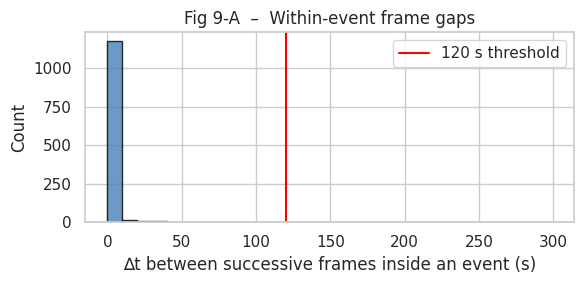

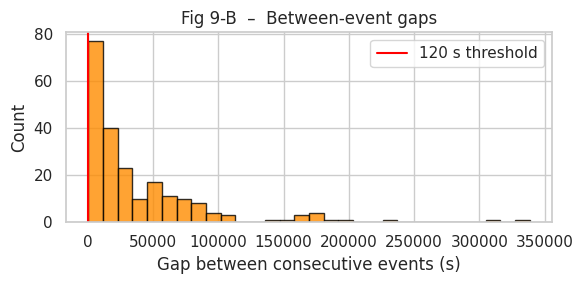

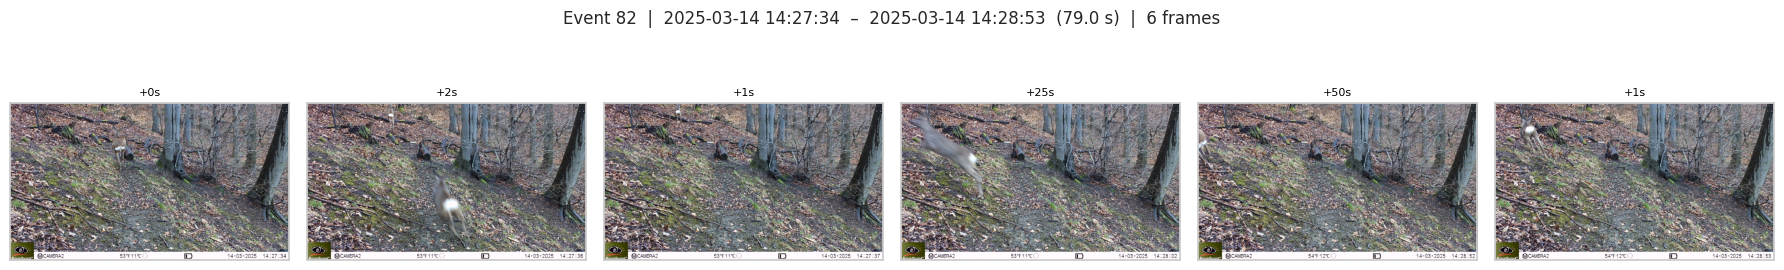

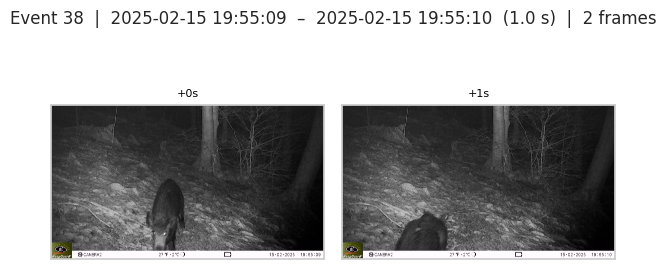

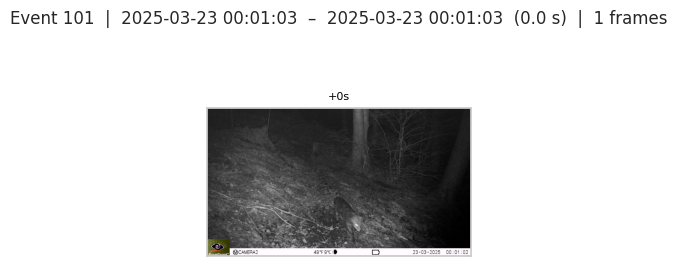

In [9]:
# ===============================================================
#  EVENT-GAP VALIDATION
#    • Fig 9-A  = within-event frame gaps
#    • Fig 9-B  = between-event gaps
#    • Fig 9-C  = thumbnail strips with ∆t labels (red ≥120 s)
# ---------------------------------------------------------------
#  Requires:  event_summary.json
#             speciesnet_groupd_moonphase.json   (per-image metadata)
# ===============================================================

import json, math, random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------- configuration --------------------------------------
EVENT_FILE   = DATA_DIR/Path("event_summary.json")
IMAGE_FILE   = DATA_DIR/Path("speciesnet_groupd_moonphase.json")
IMG_ROOT     = DATA_DIR         # prepend to stored filepaths if needed
GAP_THRESH   = 120                 # threshold you want to validate
N_EVENTS     = 3                   # random events to visualise
SEED         = 7                   # change for different random picks
# ----------------------------------------------------------------

# 1. load data ---------------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = pd.json_normalize(events).sort_values("start_time").reset_index(drop=True)

imgs = pd.json_normalize(json.loads(IMAGE_FILE.read_text()))
images_df = imgs[["filepath", "timestamp", "event_id"]].copy()
images_df["timestamp"] = pd.to_datetime(images_df["timestamp"])

# ----------------------------------------------------------------
# 2.  WITHIN-event gaps  (Fig 9-A)
# ----------------------------------------------------------------
within = []
for ev_id, g in images_df.groupby("event_id"):
    times = g.sort_values("timestamp")["timestamp"].values
    if len(times) > 1:
        within.extend(np.diff(times).astype("timedelta64[s]").astype(int))

plt.figure(figsize=(6,3))
plt.hist(within, bins=30, color="steelblue", edgecolor="black", alpha=0.8)
plt.axvline(GAP_THRESH, color="red", lw=1.5, label=f"{GAP_THRESH} s threshold")
plt.xlabel("∆t between successive frames inside an event (s)")
plt.ylabel("Count")
plt.title("Fig 9-A  –  Within-event frame gaps")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 3.  BETWEEN-event gaps  (Fig 9-B)
# ----------------------------------------------------------------
events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["end_time"]   = pd.to_datetime(events_df["end_time"])
events_sorted = events_df.sort_values("start_time")
between = (events_sorted["start_time"].iloc[1:].values -
           events_sorted["end_time"].iloc[:-1].values)\
          .astype("timedelta64[s]").astype(int)

plt.figure(figsize=(6,3))
plt.hist(between, bins=30, color="darkorange", edgecolor="black", alpha=0.8)
plt.axvline(GAP_THRESH, color="red", lw=1.5, label=f"{GAP_THRESH} s threshold")
plt.xlabel("Gap between consecutive events (s)")
plt.ylabel("Count")
plt.title("Fig 9-B  –  Between-event gaps")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 4.  Thumbnail strips for N_EVENTS random events  (Fig 9-C)
# ----------------------------------------------------------------
rnd = random.Random(SEED)
sample_ids = rnd.sample(list(events_df["event_id"]), k=min(N_EVENTS, len(events_df)))

for ev_id in sample_ids:
    subset = images_df.loc[images_df["event_id"] == ev_id].sort_values("timestamp")
    times  = subset["timestamp"].values
    deltas = np.concatenate(([0], np.diff(times).astype("timedelta64[s]").astype(int)))
    
    n_imgs = len(subset)
    ncol   = min(n_imgs, 6)
    nrow   = math.ceil(n_imgs / ncol)
    fig, axes = plt.subplots(nrow, ncol,
                             figsize=(ncol*3, nrow*3),
                             squeeze=False)
    
    row_meta = events_df.loc[events_df["event_id"]==ev_id].iloc[0]
    fig.suptitle(
        f"Event {ev_id}  |  {row_meta['start_time']}  –  {row_meta['end_time']}  "
        f"({row_meta['duration']} s)  |  {n_imgs} frames",
        fontsize=12
    )
    
    for idx, ((_, img_row), dt) in enumerate(zip(subset.iterrows(), deltas)):
        r, c = divmod(idx, ncol)
        ax = axes[r][c]
        try:
            im = Image.open(IMG_ROOT / img_row["filepath"])
            ax.imshow(im)
        except FileNotFoundError:
            ax.text(0.5, 0.5, "missing", ha="center", va="center")
        ax.set_xticks([]); ax.set_yticks([])
        color = "red" if dt >= GAP_THRESH and idx != 0 else "black"
        ax.set_title(f"+{dt}s", fontsize=8, color=color)
    
    for ax in axes.ravel()[n_imgs:]:
        ax.axis("off")
    
    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()


/tmp/ipykernel_2952158/4254653492.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  d = np.trapz(np.minimum(densities[species[i]], densities[species[j]]), grid_theta)


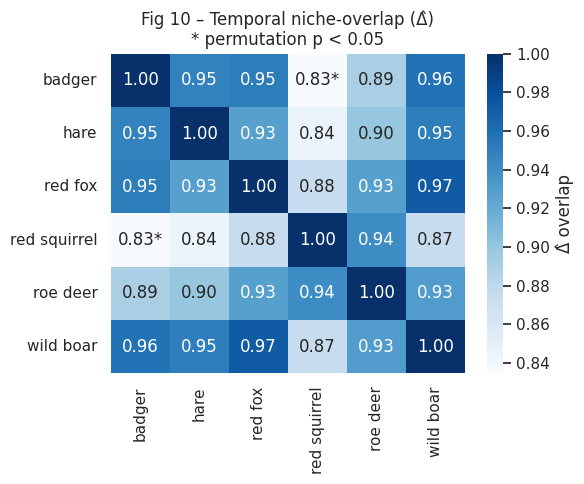

In [10]:
# =====================================================================
#  TEMPORAL OVERLAP  +  Watson U² significance (no external deps)
#    • Fig 10  = Δ̂ heat-map with * for permuted p < 0.05
# ---------------------------------------------------------------------
#  Requires: event_summary.json
# =====================================================================
import json, itertools, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# ---------- config ----------------------------------------------------
EVENT_FILE = DATA_DIR/Path("event_summary.json")
BANDWIDTH  = 0.3          # KDE smoothing for Δ̂
N_PERM     = 999          # permutations for p-value (99.9 % resolution)
GRID_N     = 512
rng        = np.random.default_rng(7)

# ---------- helper: Watson U² statistic ------------------------------
def watson_u2(theta1, theta2):
    """
    Compute Watson two-sample U² statistic (Zar 1999).
    Inputs are 1-D arrays of angles (radians) on [0, 2π).
    """
    n1, n2 = len(theta1), len(theta2)
    if n1 < 2 or n2 < 2:
        return np.nan         # not enough data
    # convert to scaled ranks on [0,1)
    u = np.sort(theta1 / (2*np.pi) % 1)
    v = np.sort(theta2 / (2*np.pi) % 1)
    w = np.concatenate([u, v])
    ranks = np.argsort(np.argsort(w)) + 1       # 1…N ranks
    F1 = np.zeros_like(w, dtype=float)
    F2 = np.zeros_like(w, dtype=float)
    F1[ranks <= n1] = np.arange(1, n1+1) / n1
    F2[ranks >  n1] = np.arange(1, n2+1) / n2
    d  = F1 - F2
    d_bar = d.mean()
    U2 = (n1*n2) / (n1 + n2)**2 * np.sum( (d - d_bar)**2 )
    return U2

def watson_perm_p(theta1, theta2, n_perm=N_PERM):
    """Permutation p-value for Watson U² (two-sided)."""
    obs = watson_u2(theta1, theta2)
    if np.isnan(obs):
        return 1.0
    pooled = np.concatenate([theta1, theta2])
    n1 = len(theta1)
    more_extreme = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        U2 = watson_u2(pooled[:n1], pooled[n1:])
        if U2 >= obs:
            more_extreme += 1
    return (more_extreme + 1) / (n_perm + 1)     # +1 rule

# ---------- load events ----------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species": "species_evt"}))
events_df["hour"]  = (pd.to_datetime(events_df["start_time"]).dt.hour +
                      pd.to_datetime(events_df["start_time"]).dt.minute/60)
events_df["theta"] = np.deg2rad(events_df["hour"] / 24 * 360)

# ---------- per-species circular KDE ---------------------------------
def circ_kde(samples, bw=BANDWIDTH, n=GRID_N):
    grid = np.linspace(0, 2*np.pi, n, endpoint=False)
    samp = np.concatenate([samples, samples+2*np.pi, samples-2*np.pi])
    kde  = gaussian_kde(samp, bw_method=bw)
    dens = kde(grid)
    return dens / (dens.sum() * (2*np.pi / n))

densities, grid_theta = {}, np.linspace(0, 2*np.pi, GRID_N, endpoint=False)
for sp, g in events_df.groupby("species_evt"):
    densities[sp] = circ_kde(g["theta"].values)

species = sorted(densities.keys())

# ---------- Δ̂ and permutation Watson U² -----------------------------
delta  = np.zeros((len(species), len(species)))
pvals  = np.ones_like(delta)

for i, j in itertools.combinations(range(len(species)), 2):
    d = np.trapz(np.minimum(densities[species[i]], densities[species[j]]), grid_theta)
    delta[i, j] = delta[j, i] = d

    th_i = events_df.loc[events_df["species_evt"]==species[i], "theta"].values
    th_j = events_df.loc[events_df["species_evt"]==species[j], "theta"].values
    pvals[i, j] = pvals[j, i] = watson_perm_p(th_i, th_j)

np.fill_diagonal(delta, 1)
np.fill_diagonal(pvals, 0)

annot = np.empty_like(delta, dtype=object)
for i, j in np.ndindex(delta.shape):
    star = "*" if pvals[i, j] < 0.05 and i != j else ""
    annot[i, j] = f"{delta[i, j]:.2f}{star}"

delta_df = pd.DataFrame(delta, index=species, columns=species)

# ---------- plot ------------------------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(delta_df, annot=annot, fmt="", cmap="Blues",
            cbar_kws={"label":"Δ̂ overlap"})
plt.title("Fig 10 – Temporal niche-overlap (Δ̂)\n* permutation p < 0.05")
plt.tight_layout()
plt.show()


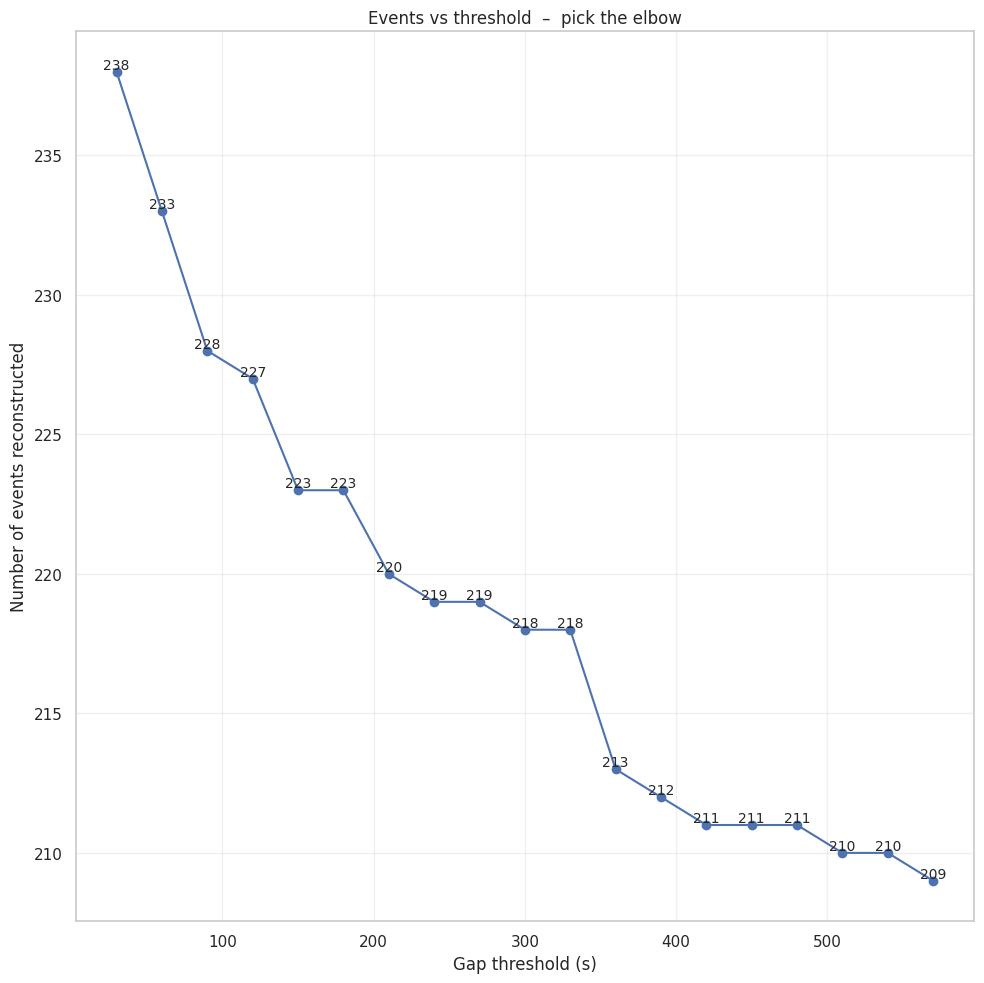

In [11]:
# ==============================================================
#  EVENT–THRESHOLD ELBOW CURVE
#    • Reads speciesnet_with_moonphase.json
#    • Re-creates events for candidate gaps (30 … 600 s)
#    • Plots event count vs threshold  →  pick the elbow
# ==============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 0.  file path  (edit if stored elsewhere)
# --------------------------------------------------------------
DETECTIONS_FILE = DATA_DIR/Path("speciesnet_with_moonphase.json")

# --------------------------------------------------------------
# 1.  load image timestamps
# --------------------------------------------------------------
preds = json.loads(DETECTIONS_FILE.read_text())["predictions"]
ts = pd.to_datetime([rec["timestamp"] for rec in preds]).sort_values().values

# --------------------------------------------------------------
# 2.  candidate thresholds (seconds)
# --------------------------------------------------------------
thresholds = np.arange(30, 600, 30)        # 30 s … 600 s in 30 s steps
event_counts = []

for thr in thresholds:
    gaps = np.diff(ts).astype("timedelta64[s]").astype(int)
    # start a new event whenever gap > thr
    n_events = 1 + np.sum(gaps > thr)
    event_counts.append(n_events)

# --------------------------------------------------------------
# 3.  plot
# --------------------------------------------------------------
plt.figure(figsize=(10,10))
plt.plot(thresholds, event_counts, marker="o")
plt.xlabel("Gap threshold (s)")
plt.ylabel("Number of events reconstructed")
plt.title("Events vs threshold  –  pick the elbow")
for x,y in zip(thresholds, event_counts):
    plt.text(x, y, str(y), ha="center", va="bottom", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


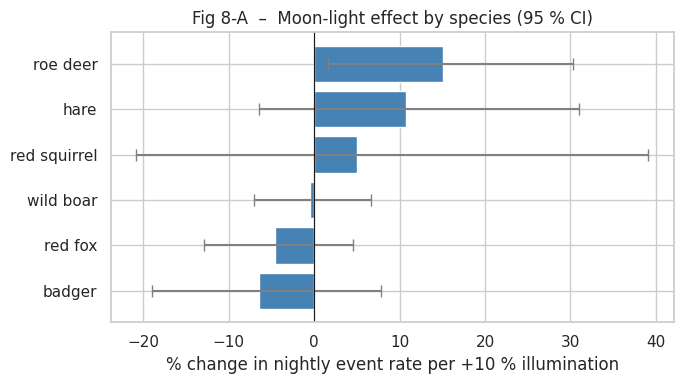

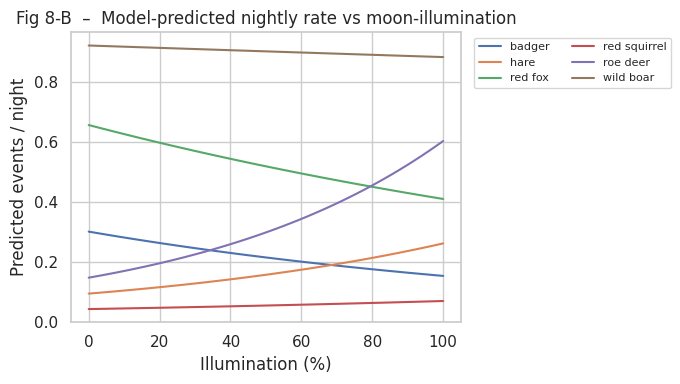


Per-species effect (% change per +10 % illumination):
(Analysis restricted to nighttime events only)


,species,pct,lo,hi,sig
0,badger,-6.5,-18.9,7.8,False
1,red fox,-4.6,-12.9,4.5,False
2,wild boar,-0.4,-7.1,6.7,False
3,red squirrel,5.0,-20.8,39.1,False
4,hare,10.7,-6.5,31.0,False
5,roe deer,15.1,1.7,30.3,True



Filtering summary:
Total events: 220
Nighttime events: 159 (72.3%)


In [12]:
# ==================================================================
#  STEP 5 – MOON-PHASE EFFECT WITH ASTROPY NIGHT FILTERING
#     • Fig 8-A  = per-species % change (+10 % illum)  ±95 % CI
#     • Fig 8-B  = predicted rate curves 0–100 % illumination
# ------------------------------------------------------------------
#  Requires:  event_summary.json
# ==================================================================
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from astropy.coordinates import get_sun, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

sns.set(style="whitegrid")

EVENT_FILE = DATA_DIR/Path("event_summary.json")       # edit if needed

# Define your camera trap location (replace with actual coordinates)
CAMERA_LAT = 45.0  # replace with your camera's latitude
CAMERA_LON = 15.0  # replace with your camera's longitude
location = EarthLocation(lat=CAMERA_LAT*u.deg, lon=CAMERA_LON*u.deg)

# Function to determine if a timestamp is during night (sun below horizon)
def is_night(timestamp):
    time = Time(timestamp)
    sun_altaz = get_sun(time).transform_to(AltAz(obstime=time, location=location))
    return sun_altaz.alt < 0*u.deg

# ---------------------------------------------------------------
# 1.  load events  → events_df (one row / event-species)
# ---------------------------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species": "species_evt"}))

events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["night"] = events_df["start_time"].dt.floor("D")
events_df["illum_norm"] = events_df["moon_phase"] / 100       # 0-1 scale

# Apply night filtering using Astropy
# Note: This can be slow for large datasets, consider vectorizing or batch processing
events_df["is_night"] = events_df["start_time"].apply(is_night)

# Filter to include only nighttime events
night_events_df = events_df[events_df["is_night"]]

# ---------------------------------------------------------------
# 2.  nightly illumination map (global)
# ---------------------------------------------------------------
# Use the first illumination value for each night
illum_map = (night_events_df.groupby("night")["illum_norm"]
                           .first())  # nearly constant within a night

# full monitoring date index
night_idx = pd.date_range(illum_map.index.min(),
                          illum_map.index.max(),
                          freq="D")
illum_map = illum_map.reindex(night_idx)

# ---------------------------------------------------------------
# 3.  per-species nightly event counts  →  GLM fits
# ---------------------------------------------------------------
results = {}
for sp, grp in night_events_df.groupby("species_evt"):
    # count events per night, fill zeros
    cnt = (grp.groupby("night").size()
              .reindex(night_idx, fill_value=0)
              .rename("event_cnt"))

    df = pd.DataFrame({"event_cnt": cnt,
                       "illum_norm": illum_map})\
            .dropna()  # remove nights with missing illumination data

    X = sm.add_constant(df["illum_norm"])
    y = df["event_cnt"]

    mod = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    results[sp] = mod

# ---------------------------------------------------------------
# 4.  summary table (% change per +10 % illum)
# ---------------------------------------------------------------
rows = []
for sp, mod in results.items():
    beta = mod.params["illum_norm"]
    lo, hi = mod.conf_int().loc["illum_norm"]
    pct   = (np.exp(beta*0.10) - 1) * 100
    pct_lo = (np.exp(lo*0.10) - 1) * 100
    pct_hi = (np.exp(hi*0.10) - 1) * 100
    rows.append({"species": sp, "pct": pct, "lo": pct_lo, "hi": pct_hi,
                 "sig": lo*hi > 0})
df_sum = pd.DataFrame(rows).sort_values("pct").reset_index(drop=True)

# ---------------------------------------------------------------
# 5-A.  Fig 8-A – bar-chart with 95 % CIs
# ---------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.barh(df_sum["species"], df_sum["pct"],
         xerr=[df_sum["pct"]-df_sum["lo"], df_sum["hi"]-df_sum["pct"]],
         color="steelblue", capsize=4, ecolor="gray")
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("% change in nightly event rate per +10 % illumination")
plt.title("Fig 8-A  –  Moon-light effect by species (95 % CI)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 5-B.  Fig 8-B – predicted curves 0-100 % illumination
# ---------------------------------------------------------------
illum_vals = np.linspace(0, 1, 50)
plt.figure(figsize=(7,4))
for sp, mod in results.items():
    X_pred = sm.add_constant(illum_vals)
    rate   = mod.predict(X_pred)
    plt.plot(illum_vals*100, rate, label=sp)

plt.xlabel("Illumination (%)")
plt.ylabel("Predicted events / night")
plt.title("Fig 8-B  –  Model-predicted nightly rate vs moon-illumination")
plt.legend(ncol=2, fontsize=8, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 6.  print tidy numeric table (optional)
# ---------------------------------------------------------------
print("\nPer-species effect (% change per +10 % illumination):")
print("(Analysis restricted to nighttime events only)")
display(df_sum.style.format({"pct":"{:.1f}", "lo":"{:.1f}", "hi":"{:.1f}"}))

# Optional: Print summary of filtering
total_events = len(events_df)
night_events = len(night_events_df)
print(f"\nFiltering summary:")
print(f"Total events: {total_events}")
print(f"Nighttime events: {night_events} ({night_events/total_events:.1%})")


/tmp/ipykernel_2952158/3214520467.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='species', y='count', data=group_size_df,


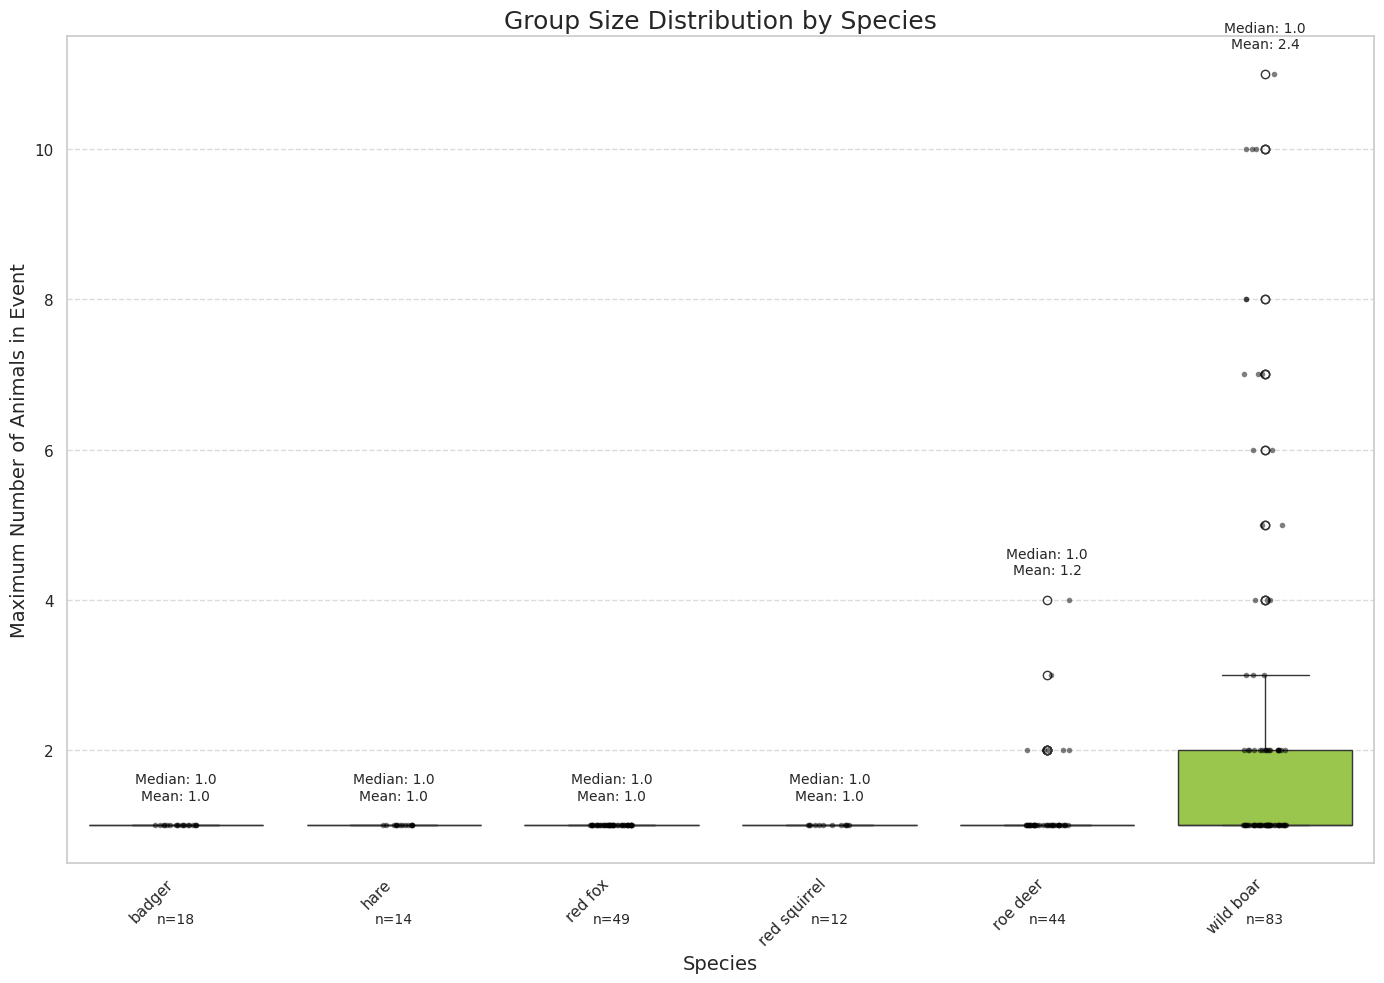

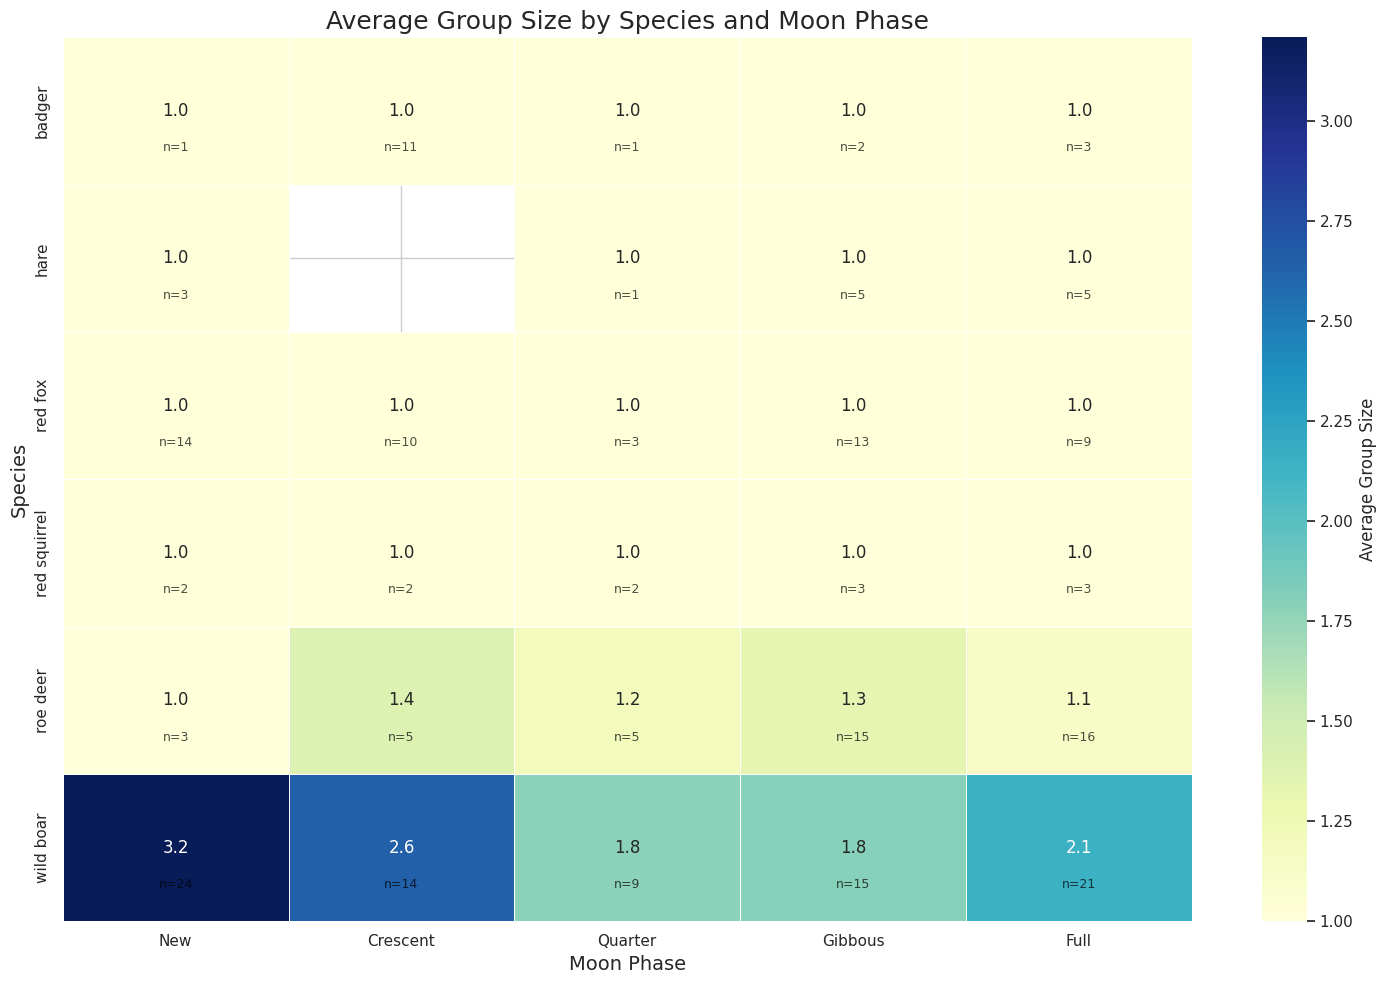

In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import matplotlib.patches as patches

def analyze_group_sizes(detection_file, event_file):
    """
    Analyze and visualize group sizes from camera trap detections.
    
    Args:
        detection_file: Path to the JSON file with animal detections
        event_file: Path to the JSON file with event summaries
    """
    # Load event data
    with open(event_file, 'r') as f:
        events_data = json.load(f)
    
    # Convert to DataFrame
    events_df = pd.DataFrame(events_data)
    events_df['start_time'] = pd.to_datetime(events_df['start_time'])
    
    # Load detections data
    with open(detection_file, 'r') as f:
        detections_data = json.load(f)['predictions']
    
    # Count animals per image and find maximum per event
    event_animal_counts = defaultdict(lambda: defaultdict(int))
    
    for detection in detections_data:
        event_id = detection.get('event_id')
        species_counts = defaultdict(int)
        
        # Count animals by species in this image
        for animal in detection.get('detections', []):
            species = animal.get('classifications', {}).get('classes', ['unknown'])[0]
            species_counts[species] += 1
        
        # Update maximum counts for this event
        for species, count in species_counts.items():
            event_animal_counts[event_id][species] = max(
                event_animal_counts[event_id][species], count)
    
    # Prepare data for visualization
    group_size_data = []
    for event_id, species_counts in event_animal_counts.items():
        event_info = next((e for e in events_data if e['event_id'] == event_id), None)
        if event_info:
            for species, count in species_counts.items():
                group_size_data.append({
                    'event_id': event_id,
                    'species': species,
                    'count': count,
                    'moon_phase': event_info['moon_phase'],
                    'moon_phase_name': event_info['moon_phase_name'],
                    'duration': event_info['duration']
                })
    
    group_size_df = pd.DataFrame(group_size_data)
    
    # Create visualizations
    create_group_size_visualizations(group_size_df, events_df)

def create_group_size_visualizations(group_size_df, events_df):
    """Create visualizations for group size analysis"""
    # Set visual style
    sns.set_style("whitegrid")
    plt.rcParams.update({'font.size': 12})
    
    # 1. Group Size by Species - Boxplot with individual points
    plt.figure(figsize=(14, 10))
    
    # Order species by median group size
    species_order = group_size_df.groupby('species')['count'].median().sort_values(ascending=False).index
    
    # Create box plot with individual points
    ax = sns.boxplot(x='species', y='count', data=group_size_df, 
                    order=species_order, palette='viridis')
    
    # Add individual observations
    sns.stripplot(x='species', y='count', data=group_size_df, 
                 order=species_order, color='black', alpha=0.5, jitter=True, size=4)
    
    # Add counts of events per species
    species_counts = group_size_df.groupby('species').size()
    for i, species in enumerate(species_order):
        plt.text(i, -0.3, f"n={species_counts[species]}", ha='center', fontsize=10)
    
    # Customize plot
    plt.title('Group Size Distribution by Species', fontsize=18)
    plt.xlabel('Species', fontsize=14)
    plt.ylabel('Maximum Number of Animals in Event', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add annotations for median and mean values
    medians = group_size_df.groupby('species')['count'].median()
    means = group_size_df.groupby('species')['count'].mean()
    
    for i, species in enumerate(species_order):
        y_pos = max(group_size_df[group_size_df['species'] == species]['count']) + 0.3
        plt.text(i, y_pos, f'Median: {medians[species]:.1f}\nMean: {means[species]:.1f}', 
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('group_size_by_species.png', dpi=300, bbox_inches='tight')
    
    # 2. Group Size by Moon Phase - Heatmap
    plt.figure(figsize=(15, 10))
    
    # Define moon phase order
    moon_phase_order = ['New', 'Crescent', 'Quarter', 'Gibbous', 'Full']
    
    # Create pivot table for the heatmap
    pivot_data = group_size_df.pivot_table(
        index='species', 
        columns='moon_phase_name',
        values='count',
        aggfunc='mean'
    ).reindex(index=species_order, columns=moon_phase_order)
    
    # Create heatmap
    ax = sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlGnBu', 
                    linewidths=0.5, cbar_kws={'label': 'Average Group Size'})
    
    # Customize plot
    plt.title('Average Group Size by Species and Moon Phase', fontsize=18)
    plt.xlabel('Moon Phase', fontsize=14)
    plt.ylabel('Species', fontsize=14)
    
    # Add annotations for sample sizes
    cell_counts = group_size_df.pivot_table(
        index='species', 
        columns='moon_phase_name',
        values='count',
        aggfunc='count'
    ).reindex(index=species_order, columns=moon_phase_order)
    
    for i, species in enumerate(species_order):
        for j, phase in enumerate(moon_phase_order):
            if not np.isnan(pivot_data.loc[species, phase]):
                count = cell_counts.loc[species, phase]
                plt.text(j+0.5, i+0.75, f'n={int(count)}', 
                        ha='center', va='center', color='black', fontsize=9, alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('group_size_by_moon_phase.png', dpi=300, bbox_inches='tight')

# Example usage
analyze_group_sizes(DATA_DIR/Path('speciesnet_with_moonphase.json'), DATA_DIR/Path('event_summary.json'))


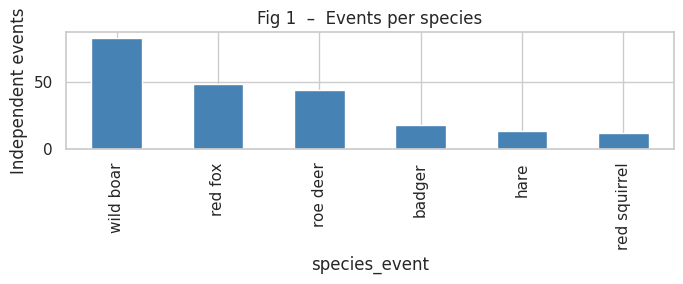

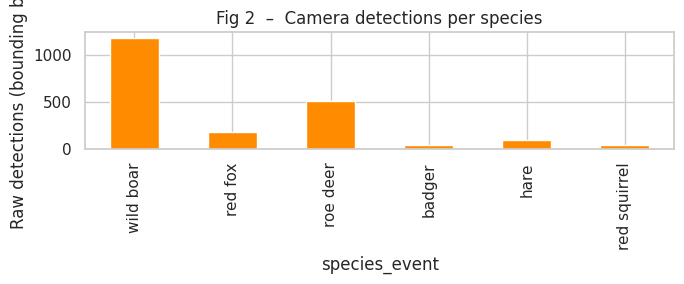

/tmp/ipykernel_2952158/2862488822.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=species_order, vert=False,


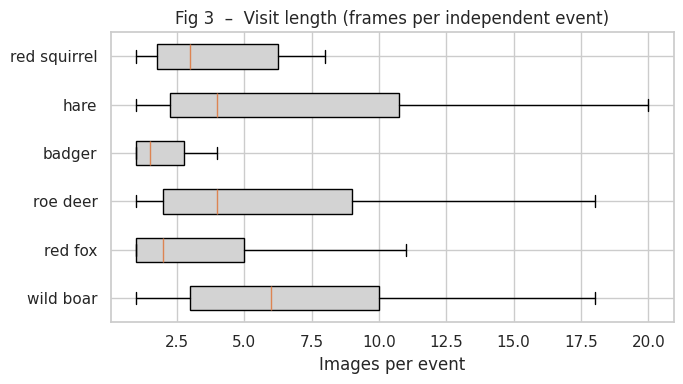

/tmp/ipykernel_2952158/2862488822.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(duration_data, labels=species_order, vert=False,


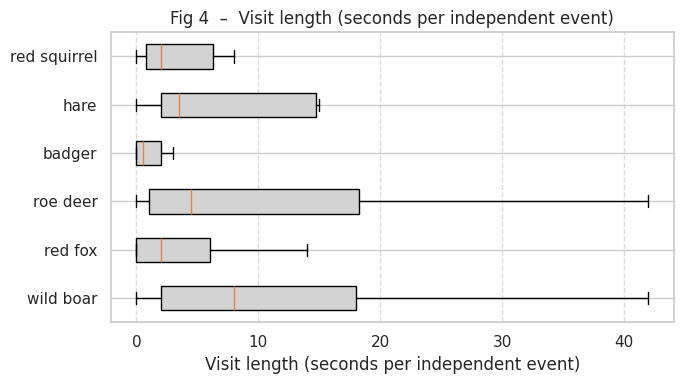

In [15]:
# ===============================================================
#  Camera-trap seminar  ·  STEP 1 — occurrence & detection pressure
#    • Fig 1  = independent events per species
#    • Fig 2  = raw detections (bounding-boxes) per species
#    • Fig 3  = images-per-event distribution (how long each visit lasts)
#    • Fig 4  = visit duration in seconds per event
# ---------------------------------------------------------------
#  Requires:  event_summary.json
#             speciesnet_with_moonphase.json          (raw detections)
# ===============================================================

import json, itertools
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 0.  file locations – edit if your paths are different
# -----------------------------------------------------------------
DATA_DIR         = Path('../data/camera_trap_dataset_filtered')                 # folder that holds the JSON files
EVENT_FILE       = DATA_DIR/'event_summary.json'
DETECTIONS_FILE  = DATA_DIR/'speciesnet_with_moonphase.json'

# -----------------------------------------------------------------
# 1.  load event summary  →  events_df
# -----------------------------------------------------------------
events_raw = json.loads(EVENT_FILE.read_text())
events_df  = (pd.json_normalize(events_raw)
                .explode('species', ignore_index=True)    # one row per event-species combo
                .rename(columns={'species':'species_event'}))

# images per event (needed later)
events_df['img_cnt'] = events_df['images'].apply(len)

# -----------------------------------------------------------------
# 2.  load *raw* detections  →  dets_df
# -----------------------------------------------------------------
dets_raw = json.loads(DETECTIONS_FILE.read_text())['predictions']

records = []
for rec in dets_raw:
    tstamp   = pd.to_datetime(rec['timestamp'])
    for det in rec['detections']:
        # take the first class label (there is always exactly one in your file)
        sp = det['classifications']['classes'][0]
        records.append({'timestamp': tstamp, 'species_det': sp})

dets_df = pd.DataFrame.from_records(records)

# -----------------------------------------------------------------
# 3.  Figure 1 – independent events per species
# -----------------------------------------------------------------
fig1_counts = (events_df['species_event']
               .value_counts()
               .sort_values(ascending=False))

plt.figure(figsize=(7,3))
fig1_counts.plot(kind='bar', color='steelblue')
plt.ylabel('Independent events')
plt.title('Fig 1  –  Events per species')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 4.  Figure 2 – raw detections per species
# -----------------------------------------------------------------
fig2_counts = (dets_df['species_det']
               .value_counts()
               .reindex(fig1_counts.index, fill_value=0))

plt.figure(figsize=(7,3))
fig2_counts.plot(kind='bar', color='darkorange')
plt.ylabel('Raw detections (bounding boxes)')
plt.title('Fig 2  –  Camera detections per species')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 5.  Figure 3 – images per event (how long a visit lasts)
# -----------------------------------------------------------------
# use same species order as Fig 1 for consistency
species_order = fig1_counts.index.tolist()
box_data = [events_df
            .loc[events_df['species_event']==sp, 'img_cnt']
            .values
            for sp in species_order]

plt.figure(figsize=(7,4))
plt.boxplot(box_data, labels=species_order, vert=False,
            showfliers=False, patch_artist=True,
            boxprops={'facecolor':'lightgrey'})
plt.xlabel('Images per event')
plt.title('Fig 3  –  Visit length (frames per independent event)')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 6.  Figure 4 – visit duration in seconds
# -----------------------------------------------------------------
# Create boxplot of event durations in seconds
duration_data = [events_df
                .loc[events_df['species_event']==sp, 'duration']
                .values
                for sp in species_order]

plt.figure(figsize=(7,4))
plt.boxplot(duration_data, labels=species_order, vert=False, 
            showfliers=False, patch_artist=True,
            boxprops={'facecolor':'lightgrey'})
plt.xlabel('Visit length (seconds per independent event)')
plt.title('Fig 4  –  Visit length (seconds per independent event)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


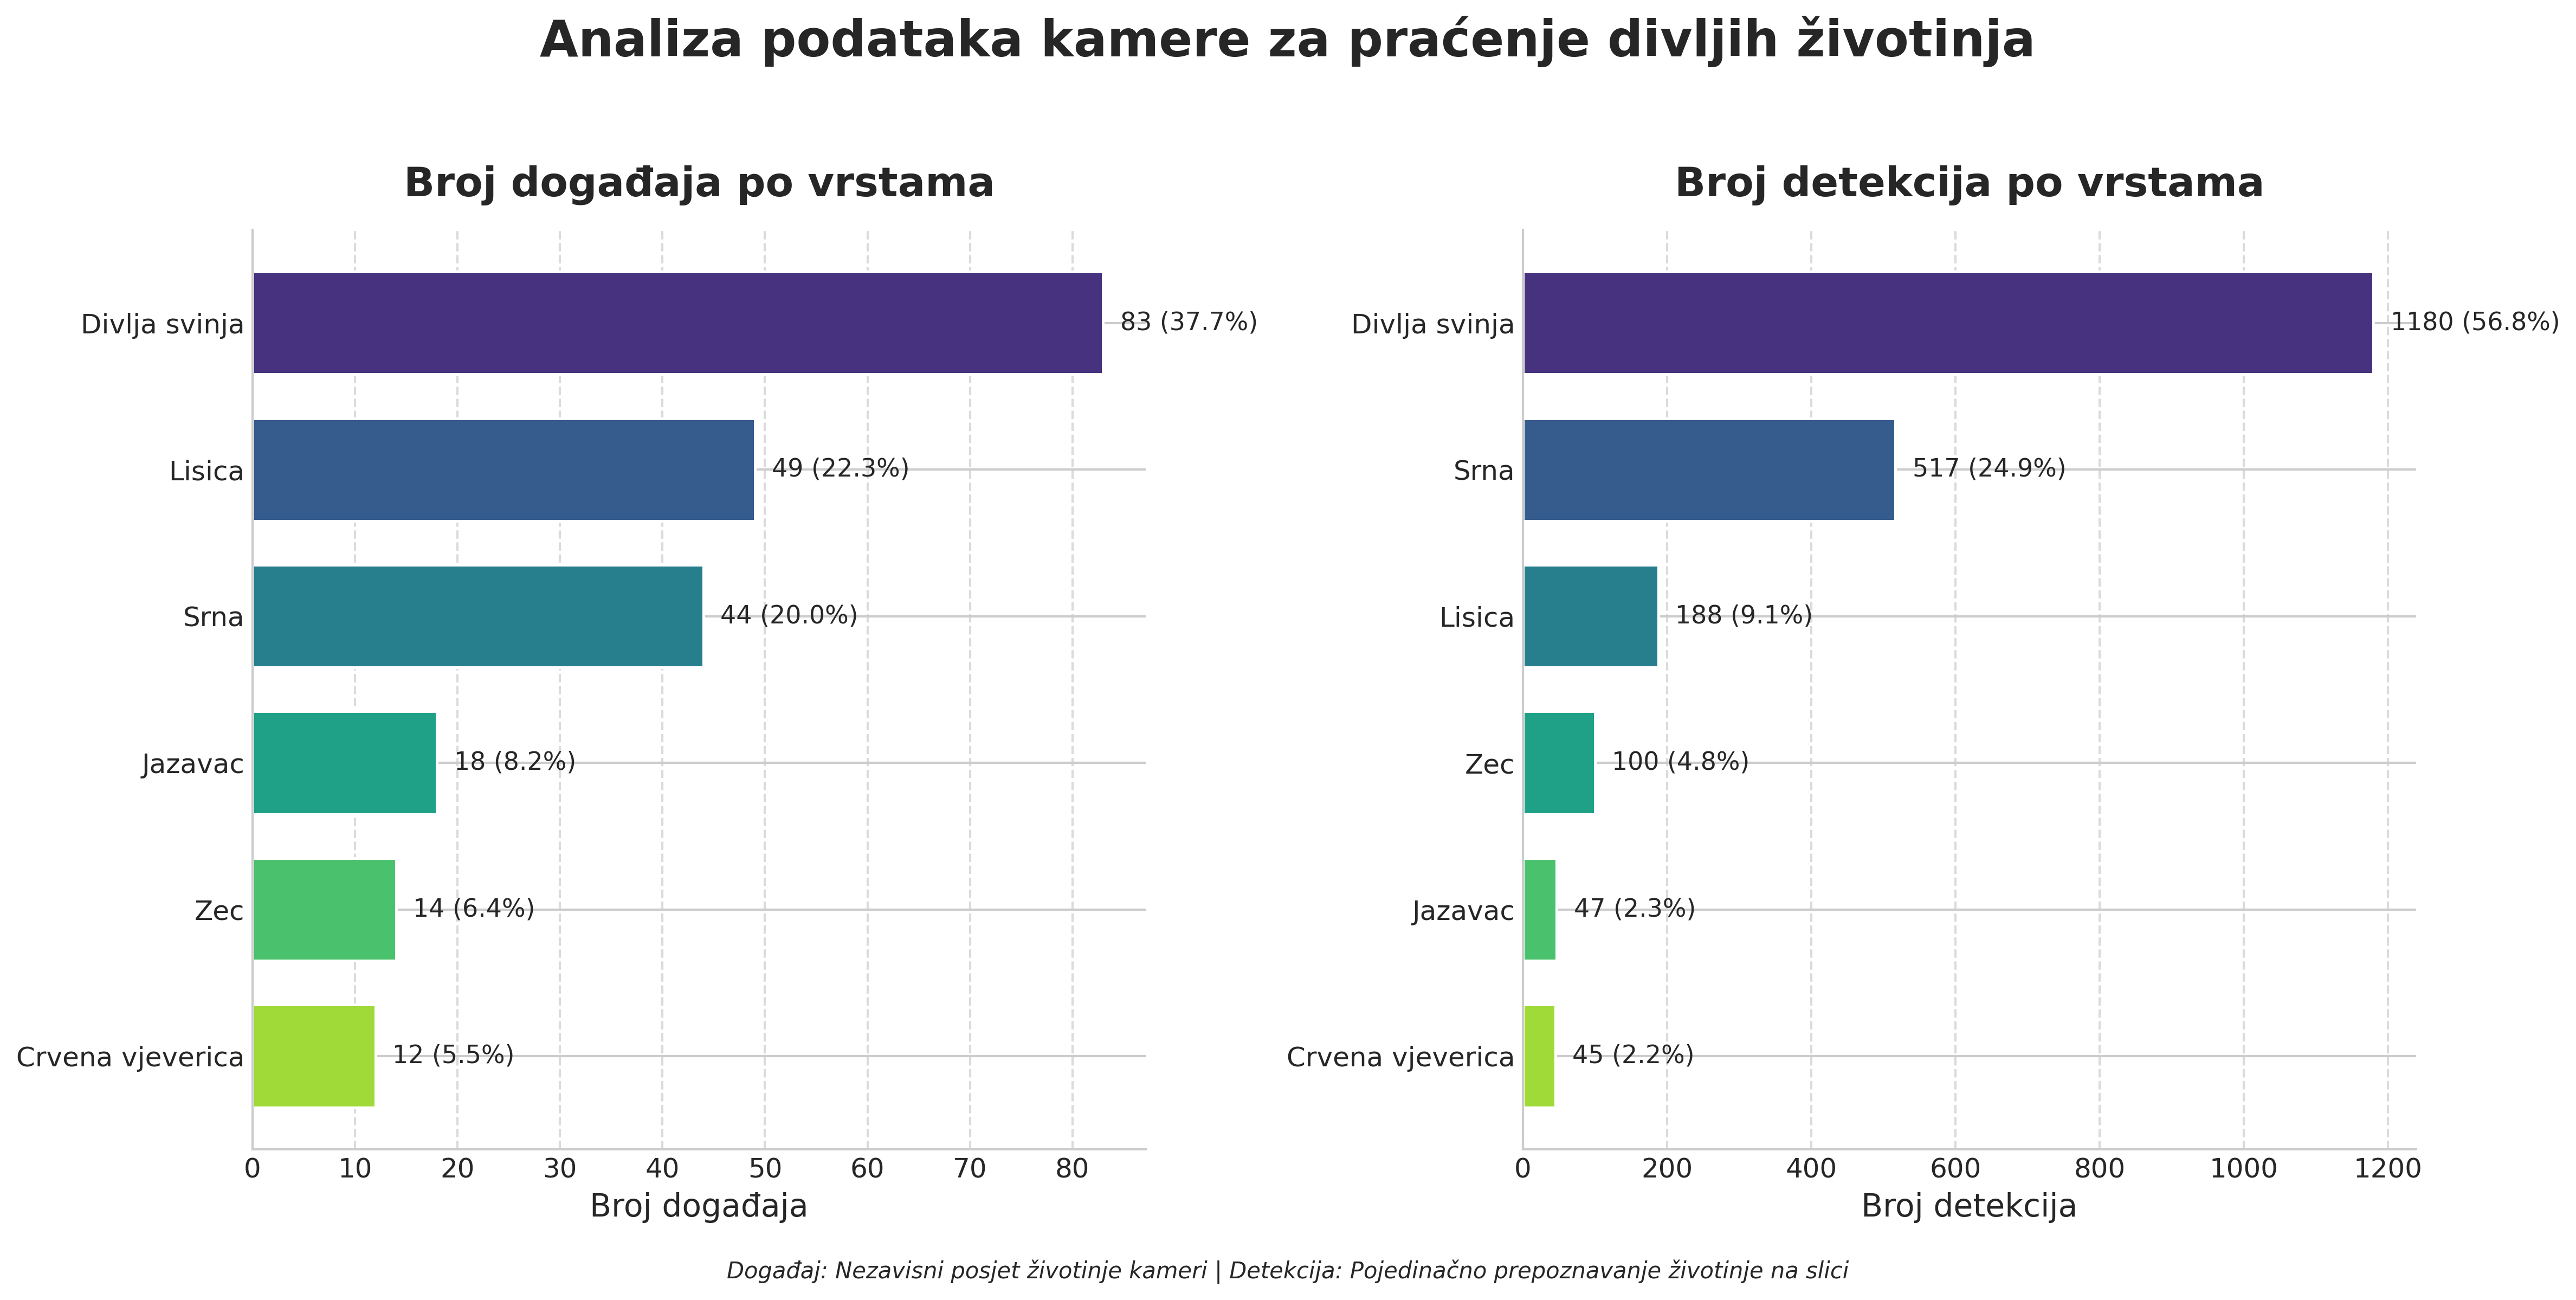

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import numpy as np

# Set high-quality visualization settings for presentation
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
rcParams['figure.dpi'] = 300  # High resolution for presentations

# English to Croatian species name mapping
species_map = {
    'wild boar': 'Divlja svinja',
    'red fox': 'Lisica',
    'roe deer': 'Srna',
    'badger': 'Jazavac',
    'hare': 'Zec',
    'red squirrel': 'Crvena vjeverica'
}

# Load events data
with open('../data/camera_trap_dataset_filtered/event_summary.json', 'r') as f:
    events = json.load(f)

# Convert to DataFrame for events analysis
events_df = pd.DataFrame(events)
events_df['start_time'] = pd.to_datetime(events_df['start_time'])
events_df['end_time'] = pd.to_datetime(events_df['end_time'])

# Load detections data - add path to your actual detections file
with open('../data/camera_trap_dataset_filtered/speciesnet_with_moonphase.json', 'r') as f:
    detections_raw = json.load(f)['predictions']

# Process detections into a flat dataframe
records = []
for rec in detections_raw:
    timestamp = pd.to_datetime(rec['timestamp'])
    for det in rec.get('detections', []):
        # Take the first class label
        species = det['classifications']['classes'][0]
        records.append({'timestamp': timestamp, 'species': species})

df_filtered = pd.DataFrame.from_records(records)

# ---------------------------------------------------------------------------------
# 1. EVENTS PER SPECIES
# ---------------------------------------------------------------------------------
# Explode the species list to get one row per event-species
events_species = pd.json_normalize(events).explode('species')
events_species_counts = events_species['species'].value_counts().reset_index()
events_species_counts.columns = ['species', 'events']
events_species_counts = events_species_counts.sort_values('events', ascending=False)

# Add Croatian names and percentages
events_species_counts['species_hr'] = events_species_counts['species'].map(species_map)
events_species_counts['percent'] = (100 * events_species_counts['events'] / 
                                   events_species_counts['events'].sum()).round(1)

# ---------------------------------------------------------------------------------
# 2. DETECTIONS PER SPECIES
# ---------------------------------------------------------------------------------
# Count detections by species
detection_counts = df_filtered['species'].value_counts().reset_index()
detection_counts.columns = ['species', 'detections']
detection_counts = detection_counts.sort_values('detections', ascending=False)

# Add Croatian names and percentages
detection_counts['species_hr'] = detection_counts['species'].map(species_map)
detection_counts['percent'] = (100 * detection_counts['detections'] / 
                              detection_counts['detections'].sum()).round(1)

# ---------------------------------------------------------------------------------
# 3. HIGH-QUALITY VISUALIZATIONS
# ---------------------------------------------------------------------------------
# Set up a color palette based on viridis (colorblind-friendly)
colors = sns.color_palette('viridis', len(events_species_counts))

# Create a 1x2 subplot with higher quality settings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('white')  # White background for presentations

# Plot 1: Events per species
bars1 = ax1.barh(events_species_counts['species_hr'], 
                events_species_counts['events'], 
                color=colors, height=0.7, 
                edgecolor='white', linewidth=1.2)

ax1.set_title('Broj događaja po vrstama', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Broj događaja', fontsize=14)
ax1.invert_yaxis()  # Largest on top
ax1.grid(axis='x', linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)  # Grid lines behind bars

# Enhanced axis styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Add counts and percentages as text labels
for i, bar in enumerate(bars1):
    count = events_species_counts['events'].iloc[i]
    percent = events_species_counts['percent'].iloc[i]
    ax1.text(bar.get_width() + max(events_species_counts['events'])*0.02, 
            bar.get_y() + bar.get_height()/2, 
            f'{count} ({percent}%)', 
            va='center', fontsize=11)

# Plot 2: Detections per species
bars2 = ax2.barh(detection_counts['species_hr'], 
                detection_counts['detections'], 
                color=colors, height=0.7, 
                edgecolor='white', linewidth=1.2)

ax2.set_title('Broj detekcija po vrstama', fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel('Broj detekcija', fontsize=14)
ax2.invert_yaxis()  # Largest on top
ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)  # Grid lines behind bars

# Enhanced axis styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Add counts and percentages as text labels
for i, bar in enumerate(bars2):
    count = detection_counts['detections'].iloc[i]
    percent = detection_counts['percent'].iloc[i]
    ax2.text(bar.get_width() + max(detection_counts['detections'])*0.02, 
            bar.get_y() + bar.get_height()/2, 
            f'{count} ({percent}%)', 
            va='center', fontsize=11)

# Add overall title
plt.suptitle('Analiza podataka kamere za praćenje divljih životinja', 
            fontsize=22, fontweight='bold', y=0.98)

# Add explanation of the difference between events and detections
fig.text(0.5, 0.01, 
        'Događaj: Nezavisni posjet životinje kameri | Detekcija: Pojedinačno prepoznavanje životinje na slici', 
        ha='center', fontsize=10, style='italic')

# Tight layout for better spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the figure in high resolution
plt.savefig('analiza_zivotinja.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()


In [18]:
events_df

,event_id,start_time,end_time,species,images,moon_phase,moon_phase_name,duration
0,0,2025-02-02 00:12:04,2025-02-02 00:12:07,[wild boar],"[animal_images/02020392.JPG, animal_images/020...",15.35,Crescent,3.0
1,1,2025-02-02 04:32:12,2025-02-02 04:33:24,[wild boar],"[animal_images/02020401.JPG, animal_images/020...",16.90,Crescent,72.0
2,2,2025-02-02 04:42:51,2025-02-02 04:42:56,[wild boar],"[animal_images/02020419.JPG, animal_images/020...",16.96,Crescent,5.0
3,3,2025-02-02 08:36:40,2025-02-02 08:36:44,[red fox],"[animal_images/02020428.JPG, animal_images/020...",18.41,Crescent,4.0
4,4,2025-02-02 18:51:40,2025-02-02 18:51:55,[wild boar],"[animal_images/02020500.JPG, animal_images/020...",22.41,Crescent,15.0
...,...,...,...,...,...,...,...,...
213,213,2025-05-09 20:46:33,2025-05-09 20:46:35,[wild boar],"[animal_images/05090460.JPG, animal_images/050...",92.92,Full,2.0
214,214,2025-05-10 01:31:40,2025-05-10 01:31:40,[hare],[animal_images/05100462.JPG],93.84,Full,0.0
215,215,2025-05-10 04:42:34,2025-05-10 04:42:34,[wild boar],[animal_images/05100463.JPG],94.42,Full,0.0
216,216,2025-05-10 05:29:04,2025-05-10 05:29:04,[wild boar],[animal_images/05100466.JPG],94.56,Full,0.0


/tmp/ipykernel_2952158/2239176773.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(duration_data, labels=croatian_labels, vert=False,


IndexError: index -1 is out of bounds for axis 0 with size 0

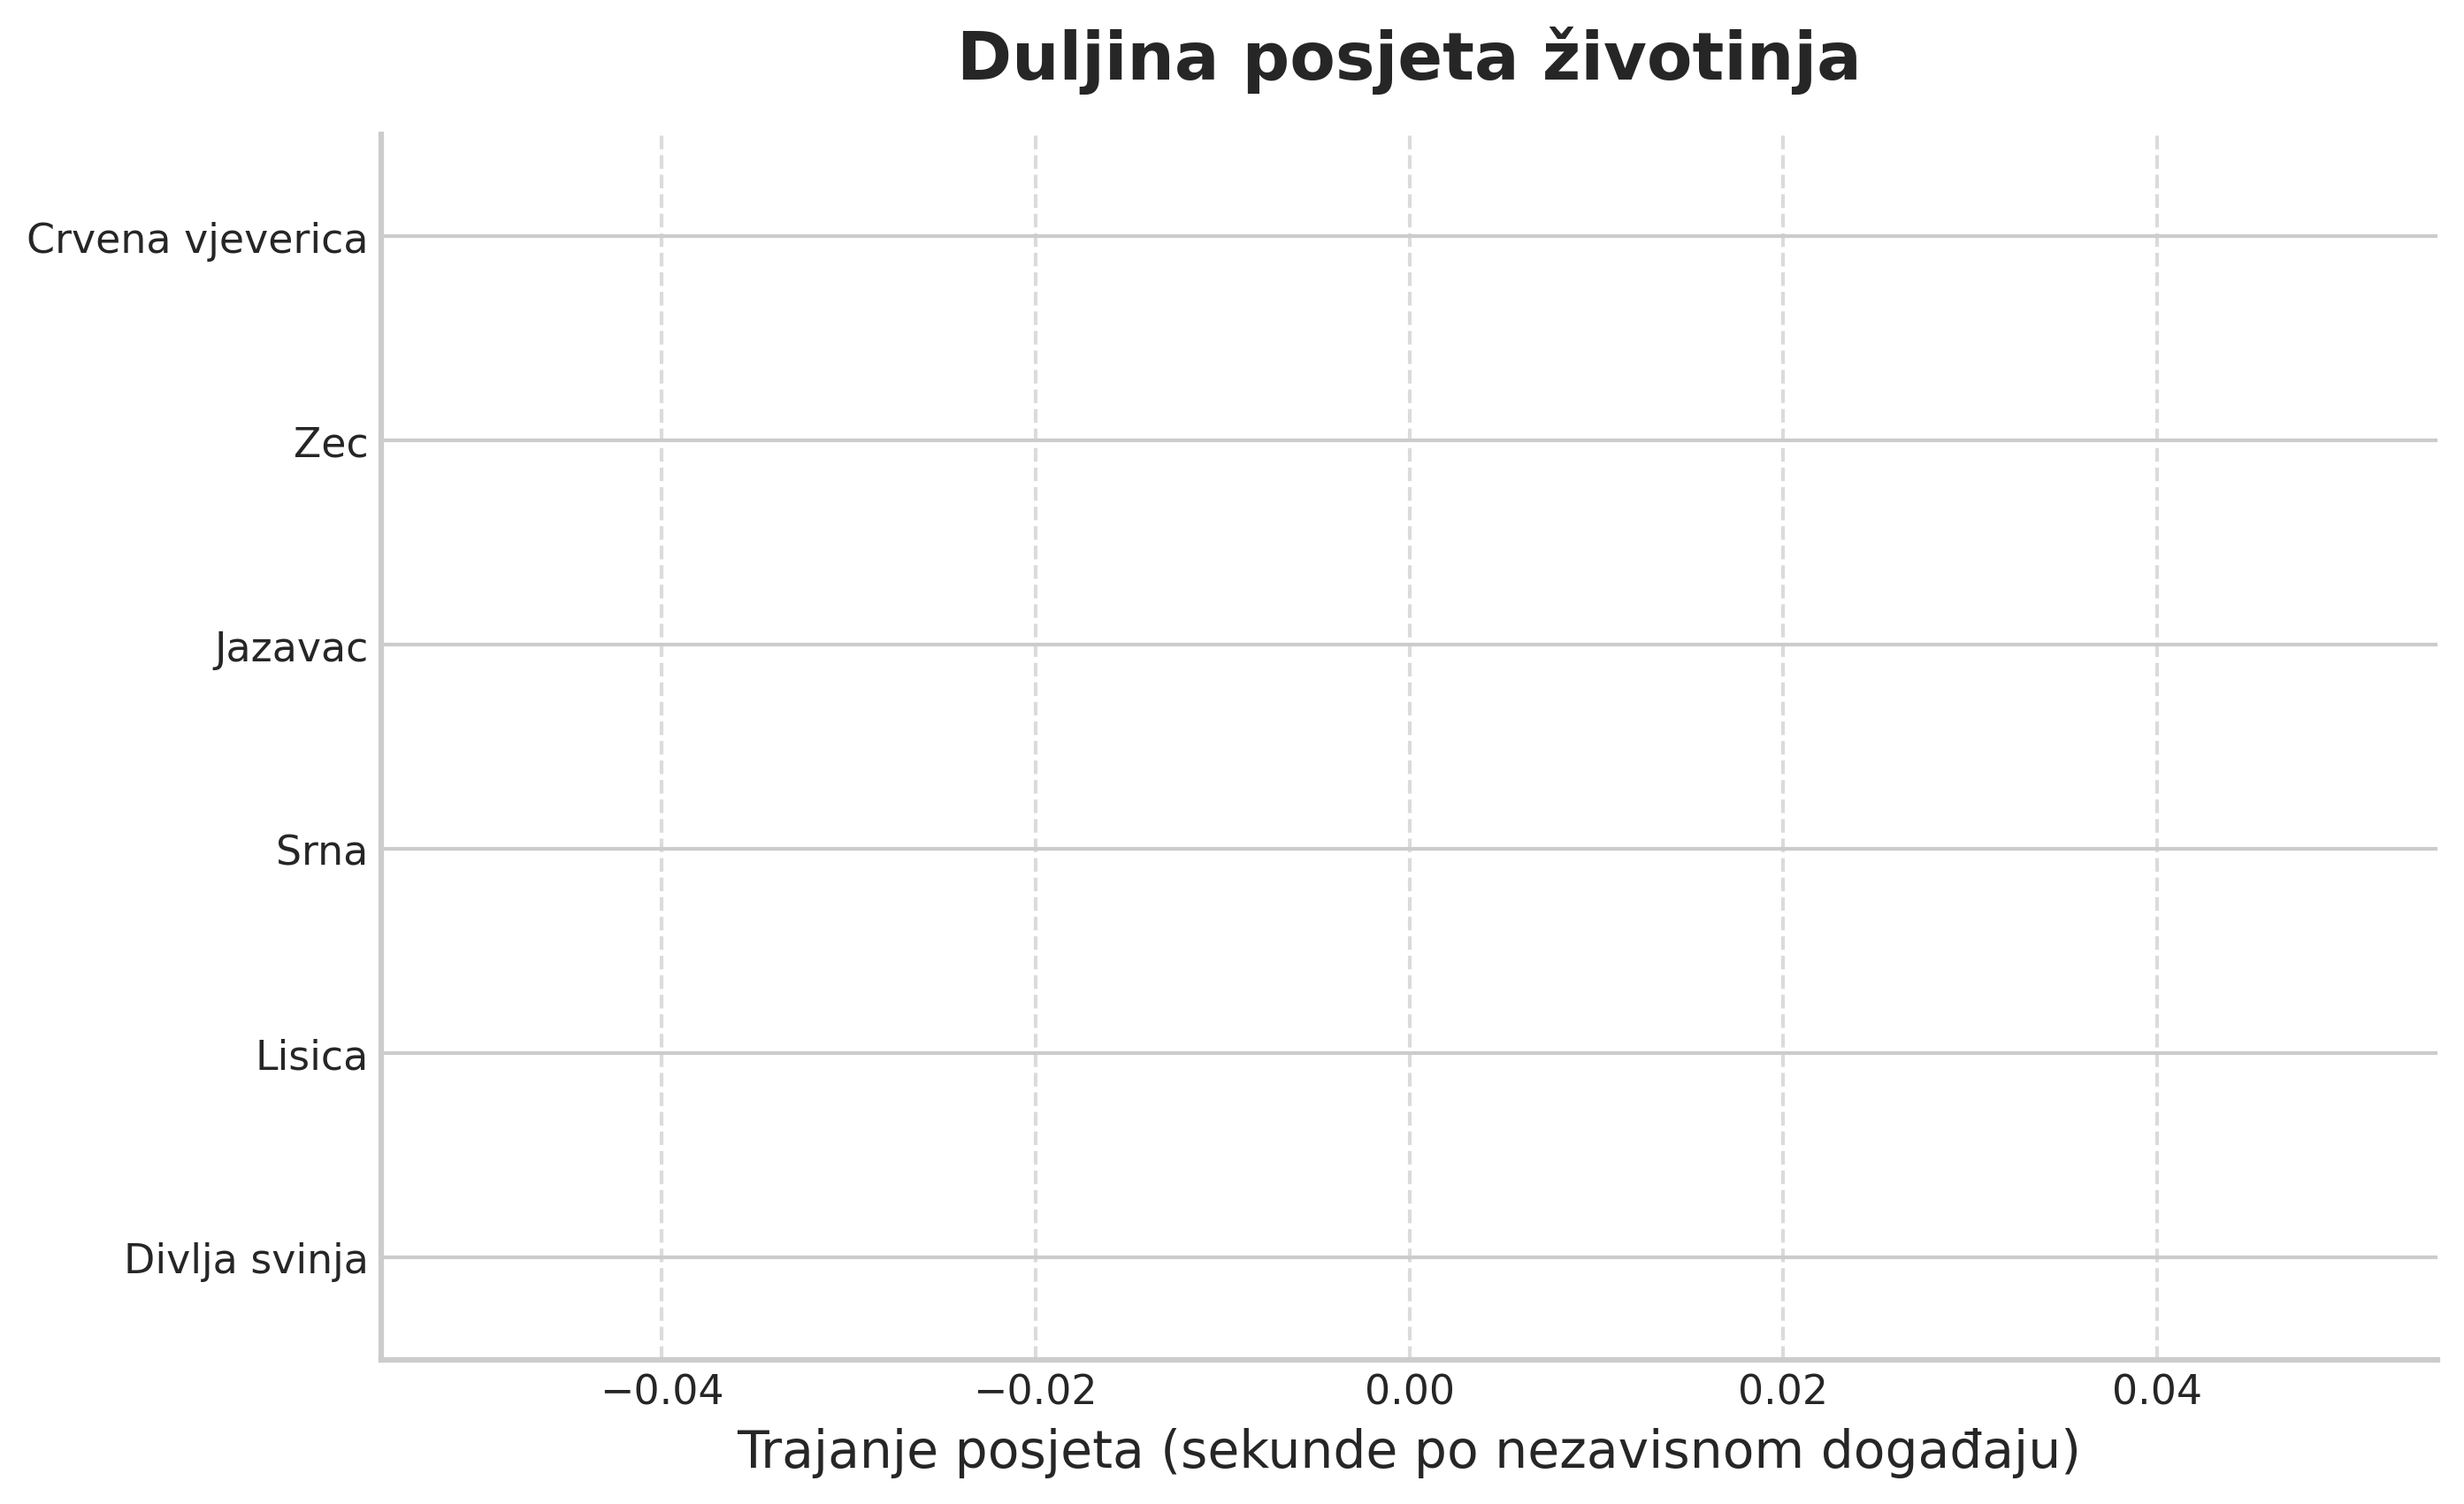

In [ ]:
# -----------------------------------------------------------------
# 6.  Figure 4 – visit duration in seconds (enhanced Croatian version)
# -----------------------------------------------------------------
import numpy as np
import seaborn as sns
from matplotlib import rcParams

# English to Croatian species name mapping
species_map = {
    'wild boar': 'Divlja svinja',
    'red fox': 'Lisica',
    'roe deer': 'Srna',
    'badger': 'Jazavac',
    'hare': 'Zec',
    'red squirrel': 'Crvena vjeverica'
}

# Map species names to Croatian
croatian_labels = [species_map.get(sp, sp) for sp in species_order]

# Create boxplot of event durations in seconds
duration_data = [events_df
                .loc[events_df['species_event']==sp, 'duration']
                .values
                for sp in species_order]

# Set up high-quality visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.dpi': 300
})

# Create the figure
fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor('white')  # White background for presentations

# Create color palette
colors = sns.color_palette('viridis', len(species_order))

# Create a better looking boxplot
bp = plt.boxplot(duration_data, labels=croatian_labels, vert=False, 
                showfliers=False, patch_artist=True)

# Customize boxplot colors
for i, box in enumerate(bp['boxes']):
    box.set(facecolor=colors[i], alpha=0.7)
    box.set(edgecolor='darkblue')

for i, median in enumerate(bp['medians']):
    median.set(color='darkblue', linewidth=2)

for prop in ['whiskers', 'caps']:
    for element in bp[prop]:
        element.set(color='darkblue', linewidth=1.5)

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Enhance spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Add title and labels with Croatian text
plt.xlabel('Trajanje posjeta (sekunde po nezavisnom događaju)', fontsize=14)
plt.title('Duljina posjeta životinja', fontsize=18, fontweight='bold', pad=15)

# Calculate max x-value for plot to place annotations
all_data = np.concatenate(duration_data)
max_x = np.percentile(all_data, 95) * 1.05  # Use 95th percentile to avoid extreme outliers

# Add annotations with statistics
for i, data in enumerate(duration_data):
    median = np.median(data)
    mean = np.mean(data)
    count = len(data)
    
    # Position annotations at a fixed percentage of the way across the plot
    plt.text(max_x * 0.75, i + 0.25, 
             f'n={count}  Med={median:.1f}s  Prosjek={mean:.1f}s',
             va='center', fontsize=10)

# Set x-axis limit to include annotations
plt.xlim(0, max_x * 1.1)

# Improve tick parameters
plt.tick_params(axis='both', which='major', labelsize=12)

# Add overall explanation
plt.figtext(0.5, 0.01, 
            'Duljina posjeta mjerena od prve do posljednje detekcije životinje u događaju',
            ha='center', fontsize=10, style='italic')

# Add tight layout for better spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Save high resolution image
plt.savefig('duljina_posjeta.png', dpi=300, bbox_inches='tight')

plt.show()


Vizualiziram 1 događaja...


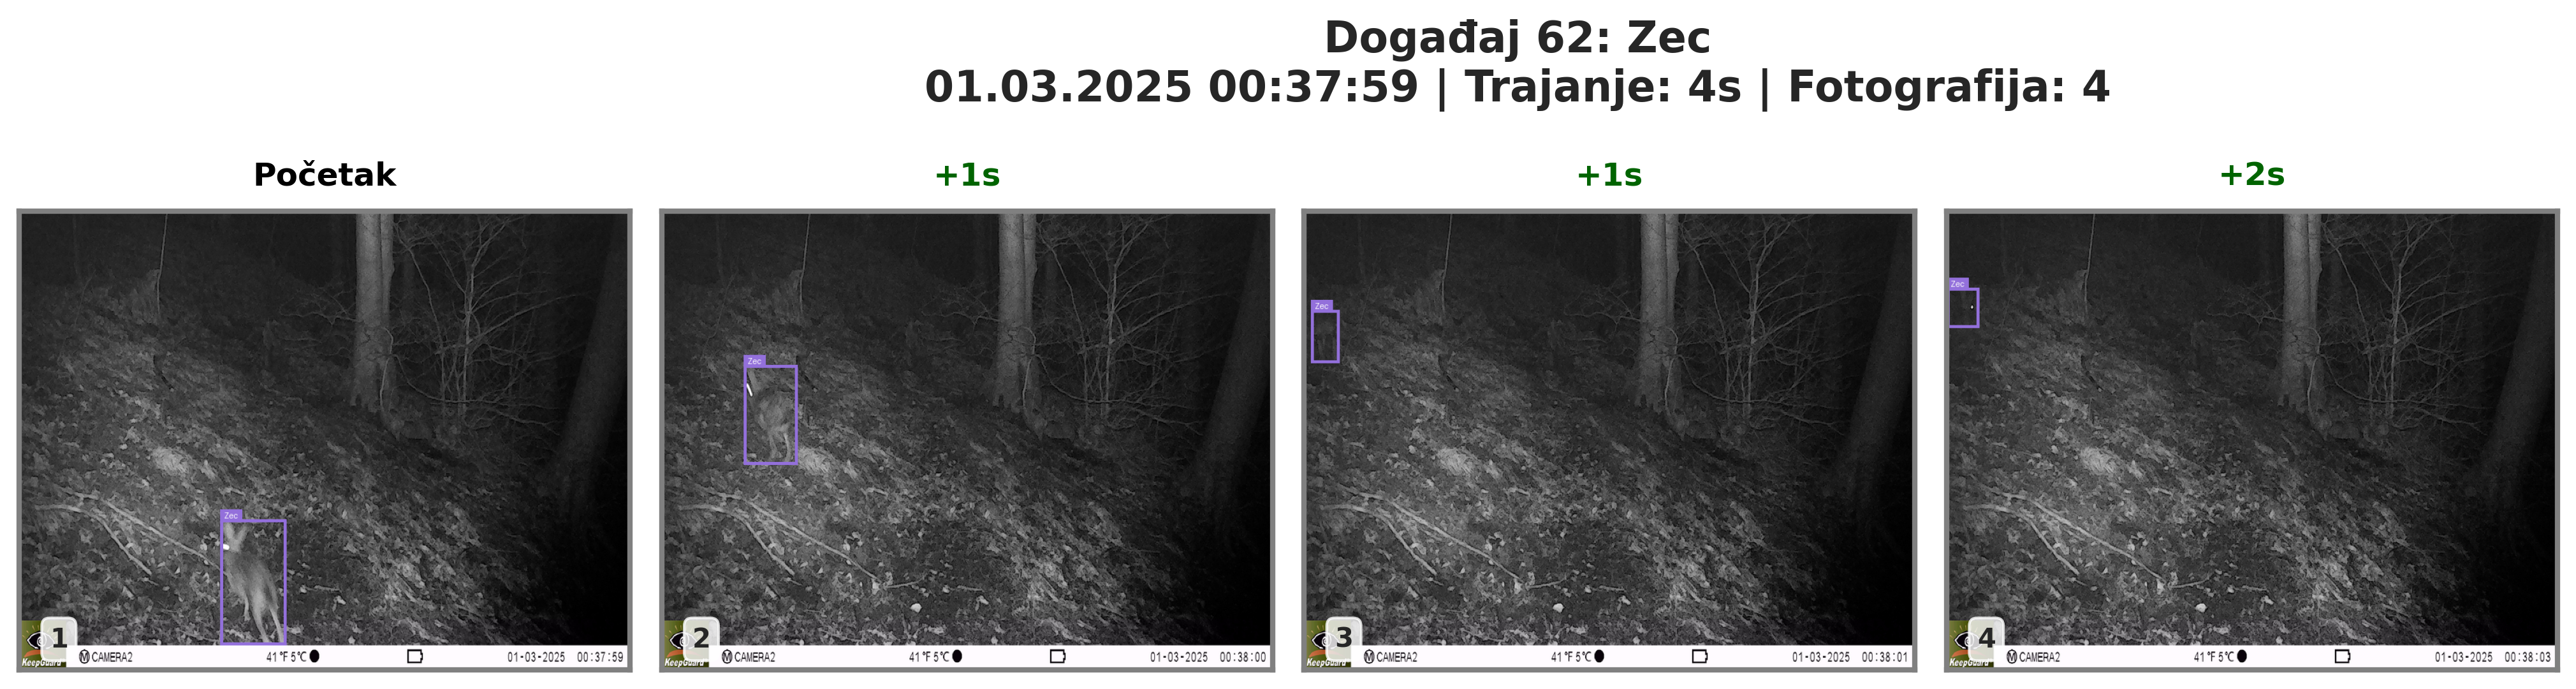


Vizualizacija završena! Generirane su slike visoke kvalitete s označenim životinjama.
Legenda boja:
  Divlja svinja: #8B4513
  Lisica: #FF4500
  Srna: #6B8E23
  Jazavac: #708090
  Zec: #9370DB
  Crvena vjeverica: #B22222


In [34]:
# ===============================================================
#  VIZUALIZACIJA DOGAĐAJA S BOUNDING BOXOVIMA - VISOKA KVALITETA
#    • Prikaz nasumičnih događaja s iscrtanim životinjama
#    • Oznake vrsta i vremenske razlike između slika
#    • Kvaliteta pogodna za seminar/prezentaciju
# ---------------------------------------------------------------
#  Requires:  speciesnet_with_moonphase.json
#             event_summary.json
# ===============================================================

import json, math, random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont
from matplotlib import rcParams
import seaborn as sns

# Set high-quality visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
rcParams['font.size'] = 11
rcParams['figure.dpi'] = 300

# Croatian species mapping
species_map = {
    'wild boar': 'Divlja svinja',
    'red fox': 'Lisica',
    'roe deer': 'Srna',
    'badger': 'Jazavac',
    'hare': 'Zec',
    'red squirrel': 'Crvena vjeverica'
}

# Configuration
DATA_FILE = DATA_DIR/Path("speciesnet_with_moonphase.json")
EVENT_FILE = DATA_DIR/Path("event_summary.json")
IMG_ROOT = DATA_DIR
GAP_THRESH = 300  # seconds
N_EVENTS = 1  # number of events to visualize
SEED = random.randint(1, 1000)         # for reproducible random selection

# Species colors for consistent visualization
species_colors = {
    'Divlja svinja': '#8B4513',    # brown
    'Lisica': '#FF4500',           # orangered
    'Srna': '#6B8E23',             # olivedrab
    'Jazavac': '#708090',          # slategray
    'Zec': '#9370DB',              # mediumpurple
    'Crvena vjeverica': '#B22222'  # firebrick
}

def draw_detections_on_image(image_path, detections, img_size=(800, 600)):
    """
    Draw bounding boxes and species labels on image
    """
    try:
        # Load and resize image
        img = Image.open(image_path)
        img = img.resize(img_size, Image.Resampling.LANCZOS)
        
        # Convert to RGB if needed
        if img.mode != 'RGB':
            img = img.convert('RGB')
            
        # Create drawing context
        draw = ImageDraw.Draw(img)
        
        # Try to load a font, fall back to default if not available
        try:
            font = ImageFont.truetype("arial.ttf", 24)
        except:
            try:
                font = ImageFont.truetype("/System/Library/Fonts/Arial.ttf", 24)
            except:
                font = ImageFont.load_default()
        
        img_width, img_height = img.size
        
        # Draw each detection
        for detection in detections:
            # Get bounding box coordinates (normalized)
            bbox = detection['bbox']
            x, y, w, h = bbox
            
            # Convert to pixel coordinates
            x1 = int(x * img_width)
            y1 = int(y * img_height)
            x2 = int((x + w) * img_width)
            y2 = int((y + h) * img_height)
            
            # Get species name
            species_en = detection['classifications']['classes'][0]
            species_hr = species_map.get(species_en, species_en)
            color = species_colors.get(species_hr, '#FF0000')
            
            # Draw bounding box
            draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
            
            # Draw label background
            text_bbox = draw.textbbox((0, 0), species_hr, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]
            
            label_x = x1
            label_y = max(0, y1 - text_height - 5)
            
            draw.rectangle([label_x, label_y, label_x + text_width + 10, 
                          label_y + text_height + 5], fill=color)
            
            # Draw species label
            draw.text((label_x + 5, label_y + 2), species_hr, 
                     fill='white', font=font)
            
            # Add confidence if needed
            conf = detection.get('conf', 1.0)
            if conf < 1.0:
                conf_text = f"({conf:.2f})"
                draw.text((label_x + 5, label_y + text_height + 7), conf_text, 
                         fill=color, font=font)
        
        return img
        
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        # Return a placeholder image
        img = Image.new('RGB', img_size, color='lightgray')
        draw = ImageDraw.Draw(img)
        draw.text((img_size[0]//2, img_size[1]//2), "Image not found", 
                 fill='black', anchor='mm')
        return img

def create_event_visualization():
    """
    Create high-quality visualization of random events with detected animals
    """
    # Load data
    with open(DATA_FILE, 'r') as f:
        detections_data = json.load(f)['predictions']
    
    with open(EVENT_FILE, 'r') as f:
        events_data = json.load(f)
    
    # Convert to DataFrame
    events_df = pd.DataFrame(events_data)
    events_df['start_time'] = pd.to_datetime(events_df['start_time'])
    events_df['end_time'] = pd.to_datetime(events_df['end_time'])
    
    # Create detections lookup by event_id
    detections_by_event = {}
    for det in detections_data:
        event_id = det['event_id']
        if event_id not in detections_by_event:
            detections_by_event[event_id] = []
        detections_by_event[event_id].append(det)
    
    # Filter events that have detections and multiple images
    valid_events = []
    for event_id, detections in detections_by_event.items():
        if len(detections) >= 3:  # At least 3 images for interesting visualization
            event_info = events_df[events_df['event_id'] == event_id]
            if not event_info.empty:
                valid_events.append(event_id)
    
    # Randomly sample events
    random.seed(SEED)
    if len(valid_events) >= N_EVENTS:
        selected_events = random.sample(valid_events, N_EVENTS)
    else:
        selected_events = valid_events
    
    print(f"Vizualiziram {len(selected_events)} događaja...")
    
    # Create visualization for each selected event
    for i, event_id in enumerate(selected_events):
        create_single_event_visualization(event_id, detections_by_event, events_df, i+1)

def create_single_event_visualization(event_id, detections_by_event, events_df, fig_num):
    """
    Create visualization for a single event
    """
    event_detections = detections_by_event[event_id]
    event_info = events_df[events_df['event_id'] == event_id].iloc[0]
    
    # Sort detections by timestamp
    event_detections.sort(key=lambda x: pd.to_datetime(x['timestamp']))
    
    # Calculate time differences
    timestamps = [pd.to_datetime(det['timestamp']) for det in event_detections]
    time_diffs = [0] + [(timestamps[i] - timestamps[i-1]).total_seconds() 
                       for i in range(1, len(timestamps))]
    
    # Determine grid layout
    n_images = len(event_detections)
    max_cols = 5
    ncols = min(n_images, max_cols)
    nrows = math.ceil(n_images / ncols)
    
    # Create figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    fig.patch.set_facecolor('white')
    
    # Handle single row case
    if nrows == 1:
        axes = axes.reshape(1, -1) if n_images > 1 else np.array([[axes]])
    
    # Get species information for the event
    all_species = set()
    for det in event_detections:
        for detection in det['detections']:
            species = detection['classifications']['classes'][0]
            all_species.add(species_map.get(species, species))
    
    species_text = ", ".join(sorted(all_species))
    
    # Main title
    start_time = event_info['start_time']
    duration = event_info['duration']
    fig.suptitle(
        f'Događaj {event_id}: {species_text}\n'
        f'{start_time.strftime("%d.%m.%Y %H:%M:%S")} | '
        f'Trajanje: {duration:.0f}s | '
        f'Fotografija: {n_images}',
        fontsize=16, fontweight='bold', y=0.95
    )
    
    # Process each image
    for idx, (detection_data, time_diff) in enumerate(zip(event_detections, time_diffs)):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row, col]
        
        # Load and process image
        img_path = IMG_ROOT / detection_data['filepath']
        processed_img = draw_detections_on_image(
            img_path, 
            detection_data['detections'],
            img_size=(800, 600)
        )
        
        # Display image
        ax.imshow(processed_img)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add time difference as title
        if idx == 0:
            title_text = "Početak"
            title_color = 'black'
        else:
            title_text = f"+{time_diff:.0f}s"
            title_color = 'red' if time_diff >= GAP_THRESH else 'darkgreen'
        
        ax.set_title(title_text, fontsize=12, fontweight='bold', 
                    color=title_color, pad=10)
        
        # Add frame number
        ax.text(0.05, 0.05, f'{idx+1}', transform=ax.transAxes,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
               fontsize=10, fontweight='bold')
        
        # Add border
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(2)
    
    # Hide unused subplots
    for idx in range(n_images, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row, col].axis('off')
    
    # Add legend for species colors
    if all_species:
        legend_elements = []
        for species in sorted(all_species):
            color = species_colors.get(species, '#000000')
            legend_elements.append(
                patches.Patch(facecolor=color, label=species)
            )
        
    
    
    plt.tight_layout(rect=[0, 0.04, 0.85, 0.92])
    plt.savefig(f'dogadaj_{event_id}_vizualizacija.png', 
               dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# Execute the visualization
create_event_visualization()

print("\nVizualizacija završena! Generirane su slike visoke kvalitete s označenim životinjama.")
print("Legenda boja:")
for species, color in species_colors.items():
    print(f"  {species}: {color}")



Analiza mjesečevog osvjetljenja:
Ukupno događaja: 220
Noćni događaji: 158 (71.8%)


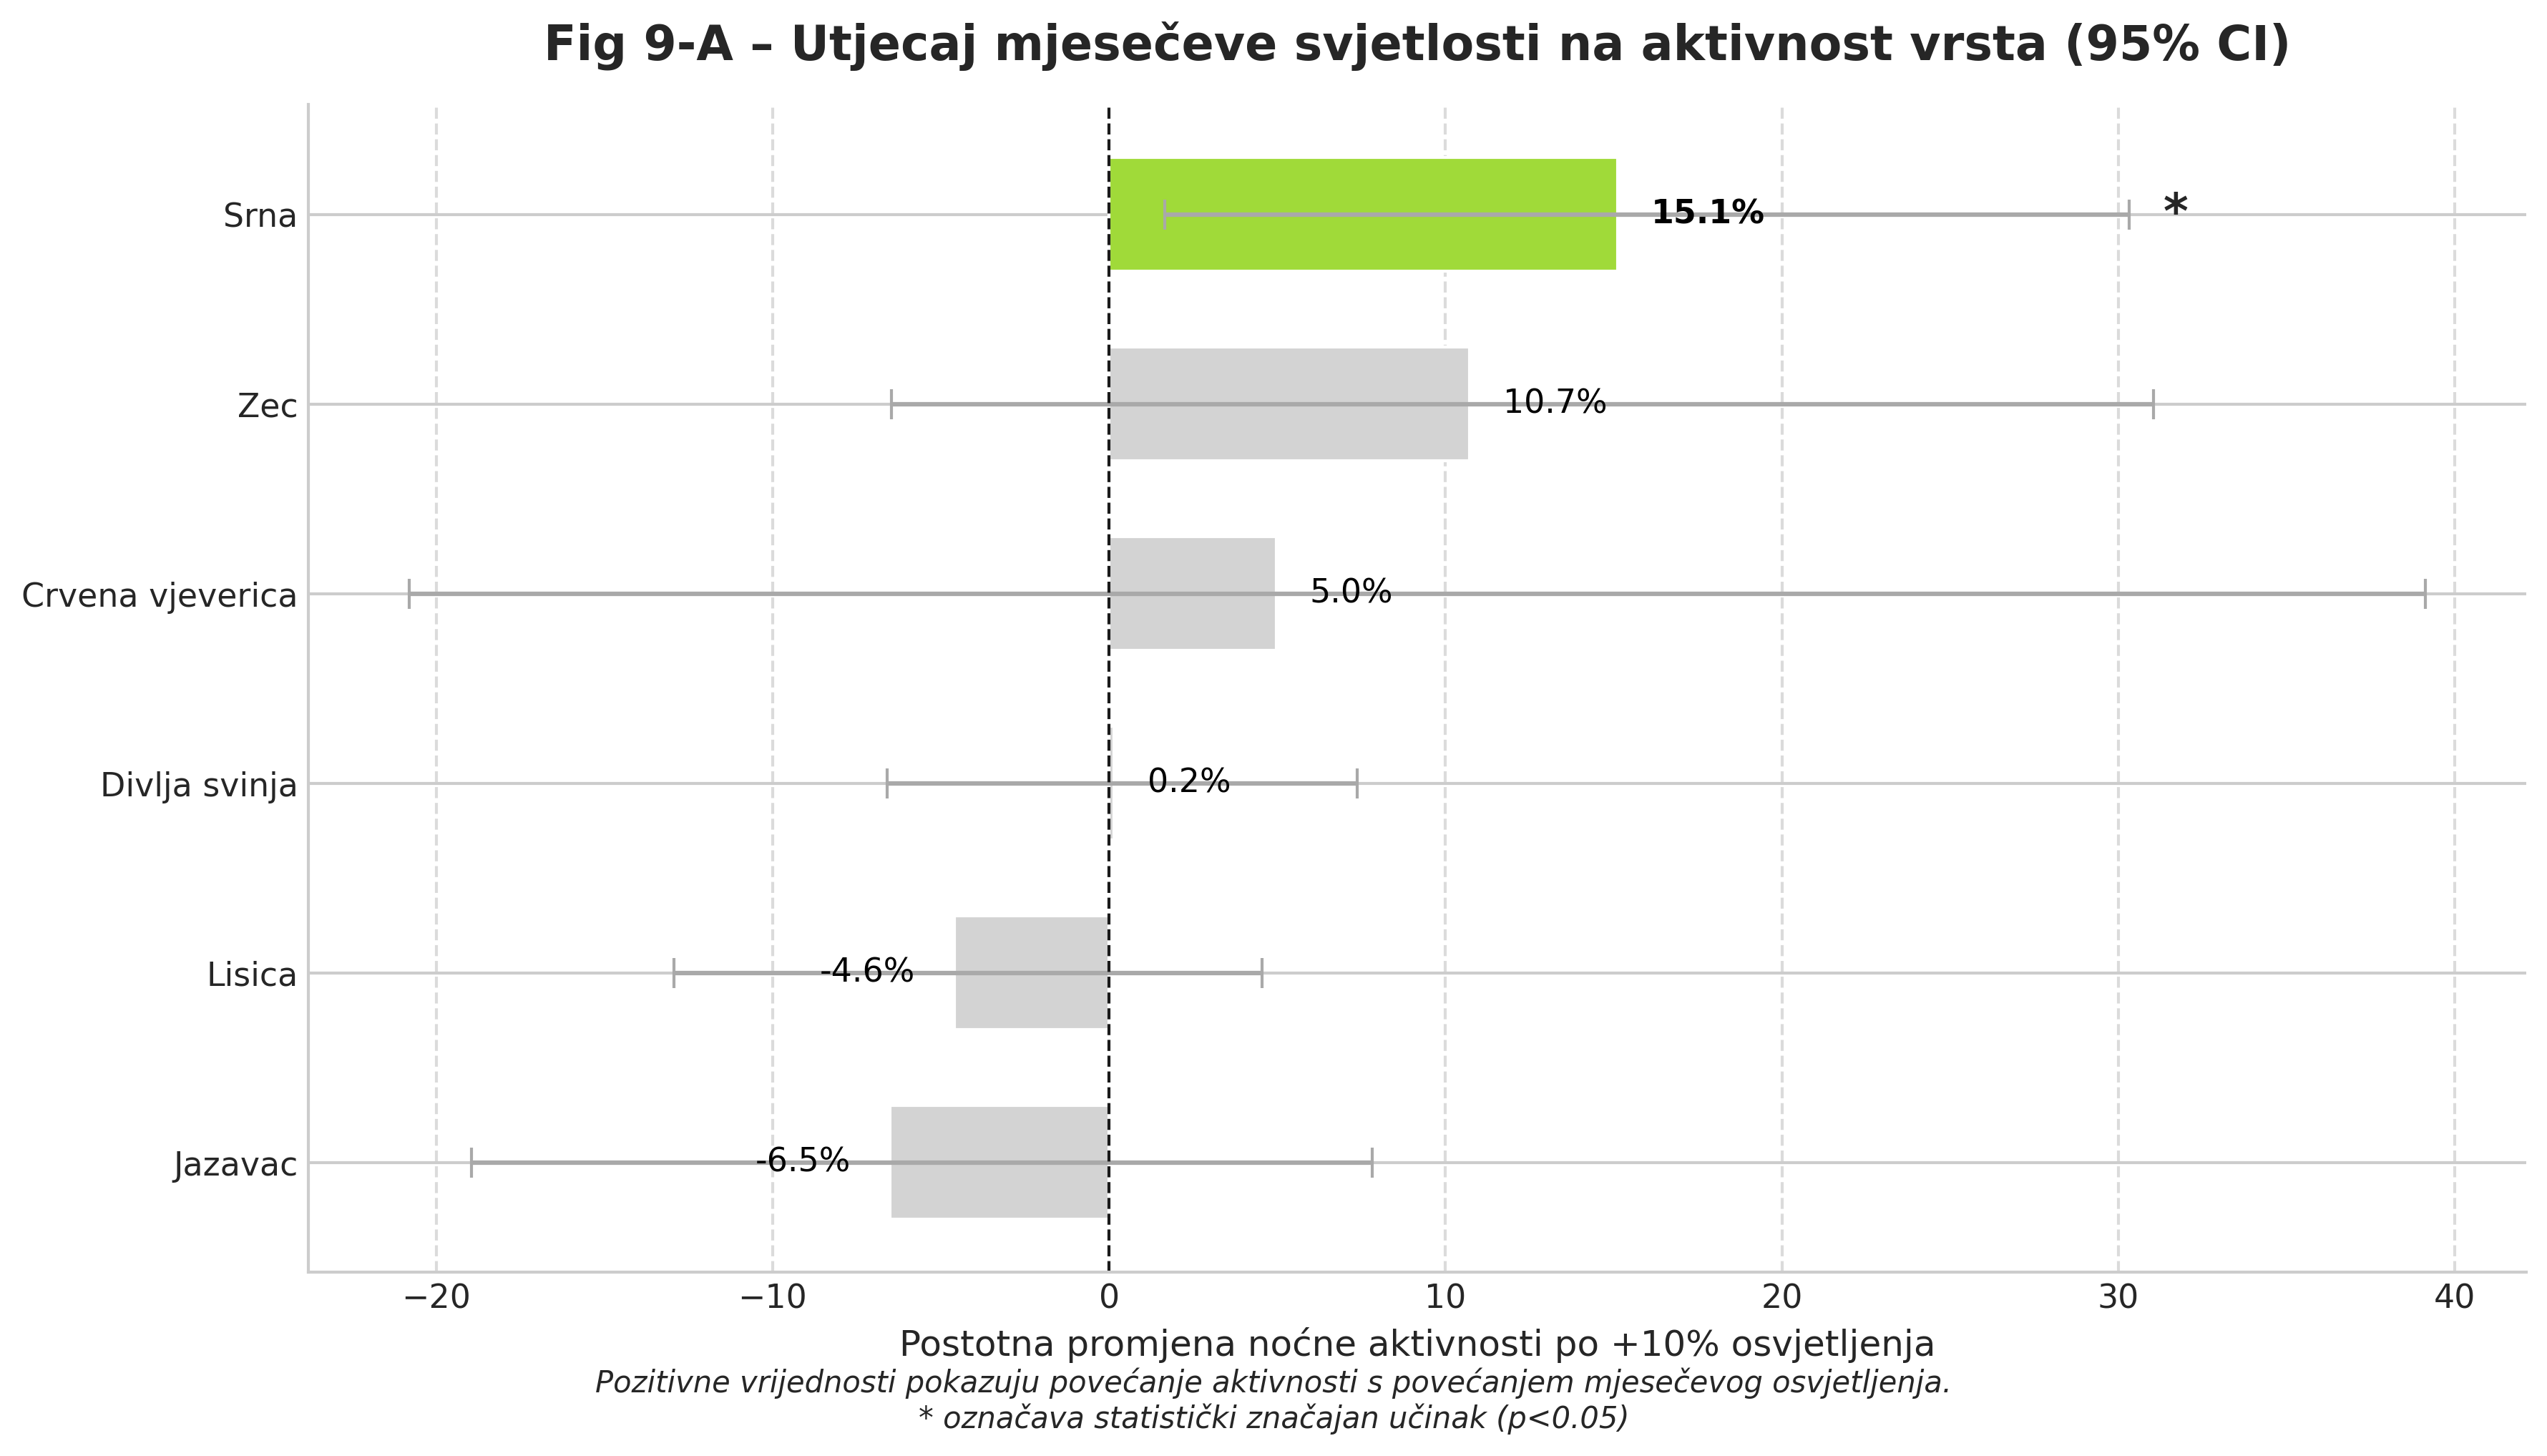

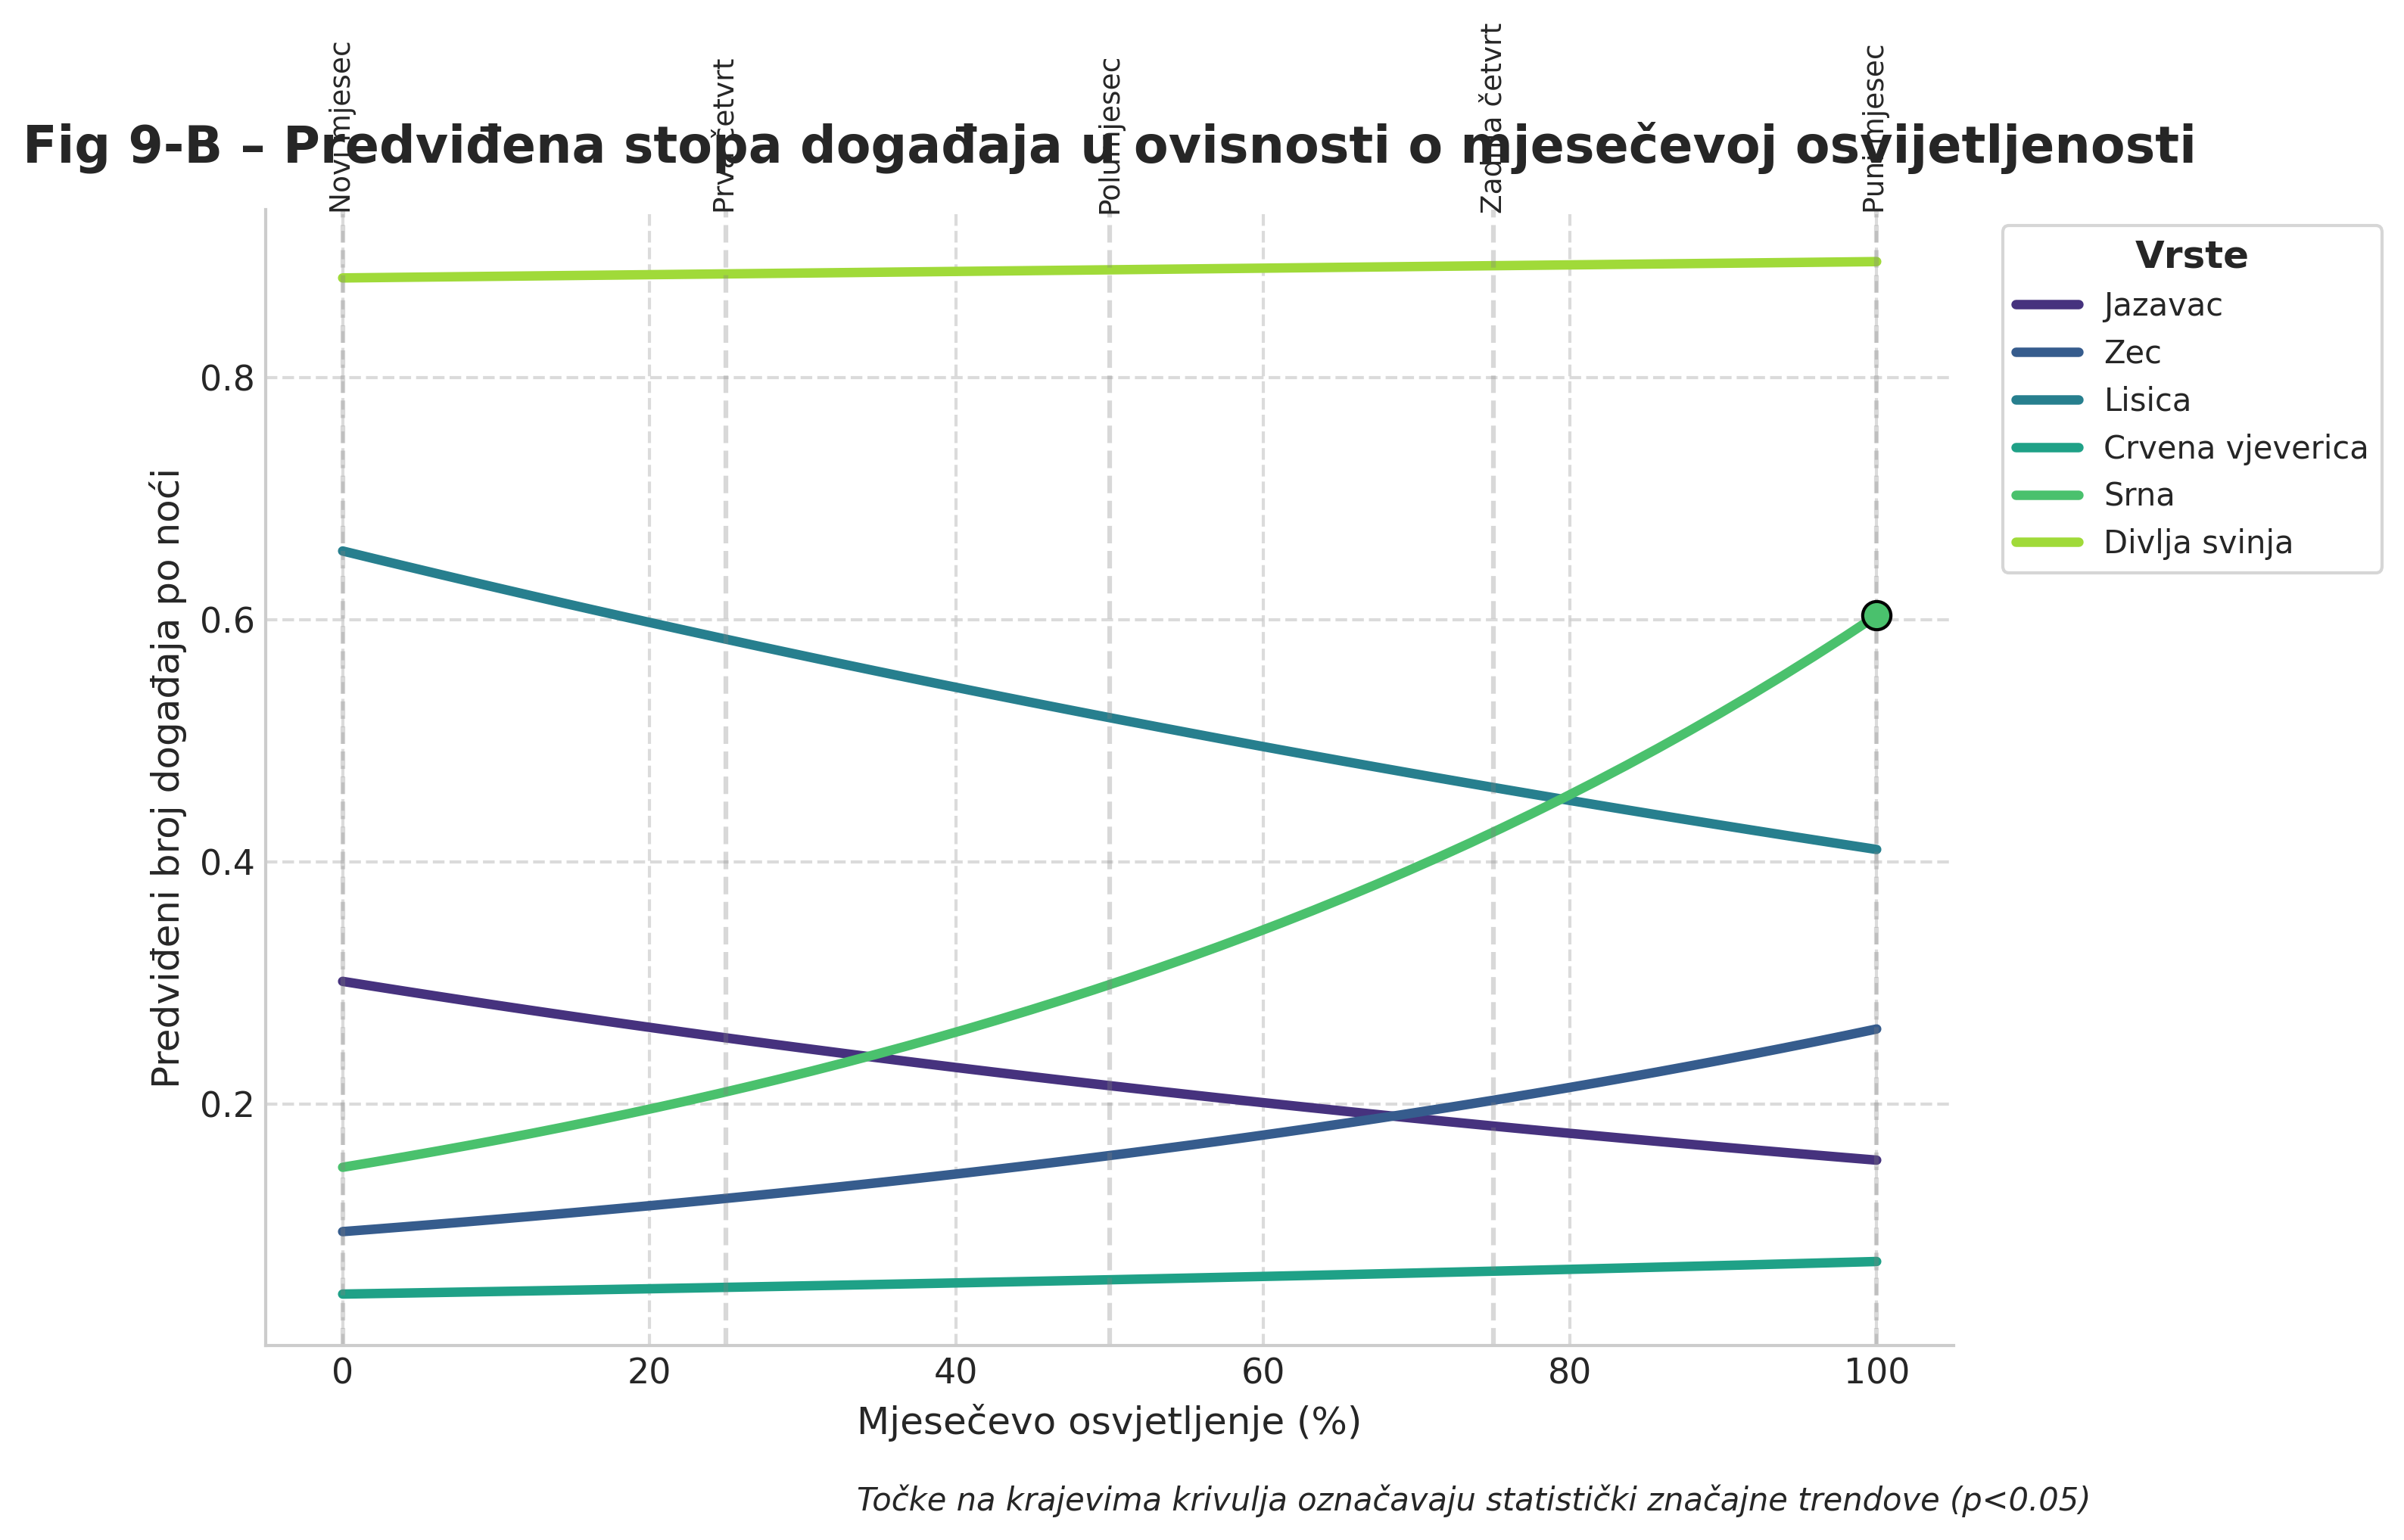

In [32]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from astropy.coordinates import get_sun, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from matplotlib import rcParams

# Set high-quality visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
rcParams['font.size'] = 11
rcParams['figure.dpi'] = 300

# English to Croatian species name mapping
species_map = {
    'wild boar': 'Divlja svinja',
    'red fox': 'Lisica',
    'roe deer': 'Srna',
    'badger': 'Jazavac',
    'hare': 'Zec',
    'red squirrel': 'Crvena vjeverica'
}

# Location configuration
EVENT_FILE = DATA_DIR/Path("event_summary.json")
CAMERA_LAT = 45.862184
CAMERA_LON = 15.945961
location = EarthLocation(lat=CAMERA_LAT*u.deg, lon=CAMERA_LON*u.deg)

# Function to determine if a timestamp is during night (sun below horizon)
def is_night(timestamp):
    time = Time(timestamp)
    sun_altaz = get_sun(time).transform_to(AltAz(obstime=time, location=location))
    return sun_altaz.alt < 0*u.deg

# ---------------------------------------------------------------
# 1.  Load events and filter for nighttime only
# ---------------------------------------------------------------
events = json.loads(EVENT_FILE.read_text())
events_df = (pd.json_normalize(events)
               .explode("species")
               .rename(columns={"species": "species_evt"}))

events_df["start_time"] = pd.to_datetime(events_df["start_time"])
events_df["night"] = events_df["start_time"].dt.floor("D")
events_df["illum_norm"] = events_df["moon_phase"] / 100       # 0-1 scale

# Apply night filtering using Astropy
events_df["is_night"] = events_df["start_time"].apply(is_night)

# Filter to include only nighttime events
night_events_df = events_df[events_df["is_night"]]

# ---------------------------------------------------------------
# 2.  Nightly illumination map
# ---------------------------------------------------------------
illum_map = (night_events_df.groupby("night")["illum_norm"]
                           .first())  # nearly constant within a night

# Full monitoring date index
night_idx = pd.date_range(illum_map.index.min(),
                          illum_map.index.max(),
                          freq="D")
illum_map = illum_map.reindex(night_idx)

# ---------------------------------------------------------------
# 3.  Per-species nightly event counts → GLM fits
# ---------------------------------------------------------------
results = {}
for sp, grp in night_events_df.groupby("species_evt"):
    # Count events per night, fill zeros
    cnt = (grp.groupby("night").size()
              .reindex(night_idx, fill_value=0)
              .rename("event_cnt"))

    df = pd.DataFrame({"event_cnt": cnt,
                       "illum_norm": illum_map})\
            .dropna()  # Remove nights with missing illumination data

    X = sm.add_constant(df["illum_norm"])
    y = df["event_cnt"]

    mod = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    results[sp] = mod

# ---------------------------------------------------------------
# 4.  Summary table (% change per +10 % illum)
# ---------------------------------------------------------------
rows = []
for sp, mod in results.items():
    beta = mod.params["illum_norm"]
    lo, hi = mod.conf_int().loc["illum_norm"]
    pct   = (np.exp(beta*0.10) - 1) * 100
    pct_lo = (np.exp(lo*0.10) - 1) * 100
    pct_hi = (np.exp(hi*0.10) - 1) * 100
    rows.append({"species": sp, 
                 "species_hr": species_map.get(sp, sp),
                 "pct": pct, 
                 "lo": pct_lo, 
                 "hi": pct_hi,
                 "sig": lo*hi > 0})
    
df_sum = pd.DataFrame(rows).sort_values("pct").reset_index(drop=True)

# ---------------------------------------------------------------
# 5-A.  Fig 9-A – Bar chart with 95% CIs
# ---------------------------------------------------------------
fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor('white')  # White background for presentation

# Create custom color palette
species_palette = sns.color_palette('viridis', len(df_sum))
colors = [species_palette[i] if row['sig'] else 'lightgray' for i, (_, row) in enumerate(df_sum.iterrows())]

# Create bar chart
bars = plt.barh(df_sum["species_hr"], df_sum["pct"],
               xerr=[df_sum["pct"]-df_sum["lo"], df_sum["hi"]-df_sum["pct"]],
               color=colors, capsize=5, ecolor="darkgray", edgecolor='white', 
               linewidth=1, height=0.6)

# Add zero line
plt.axvline(0, color="k", lw=1.0, linestyle='--')

# Add data labels
for i, bar in enumerate(bars):
    pct = df_sum["pct"].iloc[i]
    sig = df_sum["sig"].iloc[i]
    x_pos = pct + 1 if pct >= 0 else pct - 4
    plt.text(x_pos, i, f"{pct:.1f}%", va='center', 
            fontweight='bold' if sig else 'normal',
            color='black')

# Customize plot
plt.xlabel("Postotna promjena noćne aktivnosti po +10% osvjetljenja", fontsize=12)
plt.title("Fig 9-A – Utjecaj mjesečeve svjetlosti na aktivnost vrsta (95% CI)", 
         fontsize=16, fontweight='bold', pad=15)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add asterisks for significant effects
for i, (_, row) in enumerate(df_sum.iterrows()):
    if row['sig']:
        plt.text(df_sum["hi"].iloc[i] + 1, i, "*", va='center', 
                fontsize=16, fontweight='bold')

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add caption explaining interpretation
plt.figtext(0.5, 0.01, 
           "Pozitivne vrijednosti pokazuju povećanje aktivnosti s povećanjem mjesečevog osvjetljenja.\n"
           "* označava statistički značajan učinak (p<0.05)",
           ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('utjecaj_mjeseceve_svjetlosti.png', dpi=300, bbox_inches='tight')

# ---------------------------------------------------------------
# 5-B.  Fig 9-B – Predicted curves 0-100% illumination
# ---------------------------------------------------------------
fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor('white')  # White background for presentation

# Create color palette
species_palette = sns.color_palette('viridis', len(results))
species_colors = dict(zip([species_map.get(sp, sp) for sp in results.keys()], species_palette))

# Calculate predictions
illum_vals = np.linspace(0, 1, 50)
max_rate = 0

# First pass to get y-axis limits
for sp, mod in results.items():
    X_pred = sm.add_constant(illum_vals)
    rate = mod.predict(X_pred)
    max_rate = max(max_rate, rate.max())

# Second pass to plot with consistent styling
for i, (sp, mod) in enumerate(results.items()):
    X_pred = sm.add_constant(illum_vals)
    rate = mod.predict(X_pred)
    
    # Get significance status
    beta = mod.params["illum_norm"]
    lo, hi = mod.conf_int().loc["illum_norm"]
    is_sig = lo * hi > 0
    
    # Plot the curve
    plt.plot(illum_vals*100, rate, label=species_map.get(sp, sp), 
            color=species_palette[i], linewidth=3)
    
    # Add marker for significant trend
    if is_sig:
        plt.scatter([100], [rate[-1]], marker='o', s=80, 
                  color=species_palette[i], edgecolor='black', zorder=10)

# Add moon phase indicators
phase_positions = [0, 25, 50, 75, 100]
phase_names = ['Novi mjesec', 'Prva četvrt', 'Polumjesec', 'Zadnja četvrt', 'Puni mjesec']

for pos, name in zip(phase_positions, phase_names):
    plt.axvline(pos, color='gray', linestyle='--', alpha=0.3)
    plt.text(pos, max_rate * 1.05, name, ha='center', rotation=90, fontsize=9)

# Customize plot
plt.xlabel("Mjesečevo osvjetljenje (%)", fontsize=12)
plt.ylabel("Predviđeni broj događaja po noći", fontsize=12)
plt.title("Fig 9-B – Predviđena stopa događaja u ovisnosti o mjesečevoj osvijetljenosti", 
         fontsize=16, fontweight='bold', pad=15)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Create legend
leg = plt.legend(title="Vrste", fontsize=10, bbox_to_anchor=(1.02, 1), 
                loc='upper left', frameon=True)
leg.get_title().set_fontweight('bold')

# Add annotation for statistically significant trends
plt.figtext(0.5, 0.01, 
           "Točke na krajevima krivulja označavaju statistički značajne trendove (p<0.05)",
           ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.03, 0.85, 0.97])
plt.savefig('predvidena_stopa_dogadaja.png', dpi=300, bbox_inches='tight')

# Print summary statistics
total_events = len(events_df)
night_events = len(night_events_df)
print(f"\nAnaliza mjesečevog osvjetljenja:")
print(f"Ukupno događaja: {total_events}")
print(f"Noćni događaji: {night_events} ({night_events/total_events:.1%})")

plt.show()
